<h1 align="center" style="color:#4F46E5; background-color:#EEF2FF; padding:15px; border-radius:10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">🌍✈️ Conversational Travel Recommender Agent 🤖</h1>

<div style="background-color:#F0FDF4; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #22C55E;">
  <h2 style="color:#15803D;">📋 Project Overview</h2>
  <p style="color:gray">Welcome to this Capstone Project for the Google & Kaggle 5-Day Generative AI Intensive Course (2025Q1)! This notebook implements a <strong>Conversational Travel Recommender Agent</strong> named "Nomad". The agent interactively guides users through preference gathering (vibe, activities, weather, budget) using a conversational flow managed by LangGraph. It then leverages the Google Gemini API for generating personalized city recommendations, enhanced with real-world context like images and weather via Function Calling, and detailed Point of Interest (POI) information using Retrieval-Augmented Generation (RAG) on the <a href="https://github.com/baturin/wikivoyage-listings" target="_blank">Wikivoyage dataset</a>. Grounding via Google Search is used to find relevant events for the selected city.</p>
</div>

<h2 style="color:#0F766E; border-bottom:3px solid #0D9488; padding-bottom:8px;">🗺️ Approach & Capabilities Showcase</h2>

<p style="color:#374151; background-color:#EEF2FF; padding:15px; border-radius:10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">This project demonstrates a multi-phase agentic workflow orchestrated using LangGraph:</p>

<h3 style="color:#065F46;">Phase 1: Preference Gathering & Recommendation</h3>
<ol style="background-color:#ECFDF5; padding:15px 15px 15px 40px; border-radius:8px; border:2px dashed #047857;">
  <li style="color:#047857; margin-bottom:10px;"><strong>Engage User & Gather Preferences:</strong> Initiates a conversation using <strong>LangGraph</strong> to manage state. Employs an LLM (Gemini) node to ask sequential questions about travel 'vibe', 'activities', 'weather', and 'budget'.</li>
  <li style="color:#047857; margin-bottom:10px;"><strong>Parse User Input:</strong> Uses another LLM node configured for <strong>Structured Output (JSON)</strong> to reliably parse the user's responses and store them in the agent's state.</li>
  <li style="color:#047857; margin-bottom:10px;"><strong>Generate City Recommendations:</strong> Once preferences are complete, triggers an LLM call (Gemini) requesting 3-5 diverse global cities, formatted using <strong>Structured Output (JSON)</strong>.</li>
  <li style="color:#047857; margin-bottom:10px;"><strong>Verify & Enhance Recommendations:</strong> Checks generated cities against the loaded Wikivoyage dataset to flag which have detailed POI data available. Uses <strong>Function Calling</strong> to trigger parallel calls to the Unsplash API (via a custom tool) to fetch relevant images for each recommendation.</li>
  <li style="color:#047857; margin-bottom:10px;"><strong>Present & Select:</strong> Displays the recommendations with images and details in a user-friendly HTML format. Prompts the user to select a city (marked with ✅) for further exploration.</li>
</ol>

<h3 style="color:#065F46;">Phase 2: Detailed Exploration & Q&A</h3>
<ol start="6" style="background-color:#ECFDF5; padding:15px 15px 15px 40px; border-radius:8px; border:2px dashed #047857; margin-top:15px;">
  <li style="color:#047857; margin-bottom:10px;"><strong>Gather Detailed Information:</strong> For the selected city:
      <ul>
          <li>Performs <strong>RAG</strong> using ChromaDB (vector store) and Gemini embeddings (`text-embedding-004`) to find relevant POIs from Wikivoyage based on user preferences.</li>
          <li>Fetches live weather data via a <strong>direct Python call</strong> to the predefined OpenWeatherMap tool function (`get_weather`).</li>
          <li>Calls the Gemini LLM configured with <strong>Grounding</strong> (Google Search). This LLM uses the RAG context and grounding results to generate a city summary, POI descriptions, and a list of current/upcoming events, outputting them using <strong>Structured Output (JSON)</strong>. (Note: The LLM itself does not call the weather tool in this phase).</li>
      </ul>
  </li>
  <li style="color:#047857; margin-bottom:10px;"><strong>Display City Details:</strong> Presents a comprehensive overview including the generated summary, the fetched weather, suggested POIs, and events using HTML.</li>
  <li style="color:#047857;"><strong>Interactive Q&A:</strong> Enters a loop allowing the user to ask follow-up questions about the selected city. Answers are generated by:
      <ul>
          <li>Performing <strong>RAG</strong> again on the Wikivoyage POIs based on the user's question.</li>
          <li>Feeding the RAG context and conversation history to a Gemini LLM to generate a direct answer.</li>
      </ul>
  </li>
</ol>

<div style="background-color:#FFFBEB; padding:15px; border-radius:8px; margin-top:20px; border:1px solid #FBBF24;">
  <h3 style="color:#B45309;">💡 Demo Mode for Evaluation 💡</h3>
  <p style="color:#78350F;">This notebook includes a flag `INTERACTIVE_MODE` near the execution cells.
  <ul>
    <li style="color:#78350F;">Set `INTERACTIVE_MODE = True` (Default/Intended Use): Enables the full interactive experience where the agent prompts you for input via the console.</li>
    <li style="color:#78350F;">Set `INTERACTIVE_MODE = False` (For Kaggle Evaluation): The agent will use predefined demo inputs for preferences, automatically select the first valid city, and ask predefined Q&A questions. <strong>This ensures the notebook runs end-to-end without halting, as required by the competition rules.</strong></li>
  </ul>
  Please ensure `INTERACTIVE_MODE = False` if submitting for automated evaluation.
  </p>
</div>

<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; text-align:center;">🛠️ Key Technologies & Capabilities Demonstrated 💡</h2>
  <ul style="list-style-type:none; padding-left:20px;">
    <li style="color:#1E40AF; margin-bottom:8px;"><span style="display:inline-block; width:25px; text-align:center;">🧠</span> <strong>Google Gemini API:</strong> Core LLM for conversational generation, reasoning, structured output, and grounding (`gemini-2.0-flash`, `gemini-1.5-flash-latest`).</li>
    <li style="color:#1E40AF; margin-bottom:8px;"><span style="display:inline-block; width:25px; text-align:center;">🔗</span> <strong>LangGraph:</strong> Framework for building the stateful, multi-step conversational agent.</li>
    <li style="color:#1E40AF; margin-bottom:8px;"><span style="display:inline-block; width:25px; text-align:center;">📚</span> <strong>RAG (Retrieval-Augmented Generation):</strong> Using Wikivoyage POI Embeddings (`text-embedding-004`) + ChromaDB (Vector Store) for contextual POI suggestions (Phase 2) and Q&A.</li>
    <li style="color:#1E40AF; margin-bottom:8px;"><span style="display:inline-block; width:25px; text-align:center;">📞</span> <strong>Function Calling / Tool Use:</strong> Defining tools (`@tool`) for external APIs (Unsplash, OpenWeatherMap). Used via LLM-triggered calls (LangGraph `ToolNode`) in Phase 1 for images, and via direct Python invocation in Phase 2 for weather.</li>
    <li style="color:#1E40AF; margin-bottom:8px;"><span style="display:inline-block; width:25px; text-align:center;">🌐</span> <strong>Grounding (Google Search):</strong> Used by the LLM in Phase 2 to find current/upcoming events in the selected city.</li>
    <li style="color:#1E40AF; margin-bottom:8px;"><span style="display:inline-block; width:25px; text-align:center;">📋</span> <strong>Structured Output (JSON):</strong> Used for parsing user preferences, generating recommendations, and formatting detailed city information.</li>
    <li style="color:#1E40AF; margin-bottom:8px;"><span style="display:inline-block; width:25px; text-align:center;">💾</span> <strong>Vector Store:</strong> ChromaDB for persistent storage and retrieval of POI embeddings.</li>
    <li style="color:#1E40AF;"><span style="display:inline-block; width:25px; text-align:center;">📊</span> <strong>Pandas:</strong> Data loading, cleaning, and preprocessing of the Wikivoyage dataset.</li>
  </ul>
</div>

<div style="background-color:#FEF2F2; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #EF4444;">
  <h2 style="color:#B91C1C; text-align:center;">🎯 Project Goal & Capstone Evaluation</h2>
  <p style="text-align:center; color:gray">The primary goal is to build a functional prototype demonstrating the effective integration of multiple Gen AI capabilities (LangGraph, RAG, Function Calling, Grounding, Structured Output) to create a personalized, interactive travel recommender. This notebook aims to meet the Capstone evaluation criteria, focusing on <strong>Use Case/Innovation</strong> and <strong>Documentation Quality</strong>, ensuring clarity in explanations and code, and providing a non-interactive mode for evaluation.</p>
</div>

<hr style="border:0; height:3px; background-image:linear-gradient(to right, rgba(0,0,0,0), rgba(79,70,229,0.75), rgba(0,0,0,0));">

<p align="center" style="font-style:italic; color:#6B7280;">Let's embark on building our intelligent travel companion! 🗺️✨</p>

<div style="background-color:#F0FDF4; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #22C55E;">
  <h2 style="color:#15803D; border-bottom: 2px solid #16A34A; padding-bottom: 5px;">Step 1: Install Required Libraries</h2>
  <p style="color:gray; margin-top:10px;">
    This first code cell sets up the necessary Python environment for the travel recommender agent. It performs two main actions:
  </p>
  <ol style="background-color:#ECFDF5; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #D1FAE5; margin-top:10px;">
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Uninstall Conflicting Packages:</strong> Uses <code>pip uninstall -qqy</code> to silently remove potentially pre-installed versions of certain libraries (like <code>google-generativeai</code>) within the Kaggle environment. This helps prevent version conflicts with the specific versions we need.
    </li>
    <li style="color:#065F46;">
      <strong>Install Core Dependencies:</strong> Uses <code>pip install -qU</code> to quietly install or upgrade the essential packages:
      <ul style="margin-top: 5px; list-style-type: disc; padding-left: 20px;">
        <li><code>google-genai</code>: The official Google SDK for interacting with the Gemini API.</li>
        <li><code>langgraph</code>: The library for building stateful, multi-actor applications like our conversational agent.</li>
        <li><code>langchain-google-genai</code>: Provides LangChain integrations for Google's Generative AI models (used for <code>ChatGoogleGenerativeAI</code>).</li>
        <li><code>chromadb</code>: The vector database client used for storing and querying Wikivoyage POI embeddings for RAG.</li>
        <li><code>requests</code>: A standard library for making HTTP requests, needed by the Unsplash and OpenWeatherMap tools.</li>
        <li><code>Pillow</code>: The Python Imaging Library, often required for image processing tasks or displaying images (like the graph visualization).</li>
      </ul>
    </li>
  </ol>
</div>

In [1]:
!pip uninstall -qqy google-generativeai kfp jupyterlab-lsp jupyterlab

!pip install -qU \
    'google-genai==1.7.0' \
    'langgraph==0.3.21' \
    'langchain-google-genai==2.1.2' \
    'chromadb==0.6.3' \
    'requests' \
    'Pillow' \

print("Required packages installed.") 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.9/100.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 5.2 MB/s eta 0

<div style="background-color:#F0FDF4; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #22C55E;">
  <h2 style="color:#15803D; border-bottom: 2px solid #16A34A; padding-bottom: 5px;">Step 2: Import Libraries & Configure API Keys</h2>
  <p style="color:gray; margin-top:10px;">
    With the required packages installed, this cell imports necessary libraries and attempts to configure the API keys needed for the agent's functionality, designed to run even if keys are missing. It also introduces the `INTERACTIVE_MODE` flag.
  </p>
  <ul style="background-color:#ECFDF5; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #D1FAE5; margin-top:10px; list-style-type: square;">
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Interaction Mode Flag:</strong> Defines `INTERACTIVE_MODE`. Set this to `False` for the non-interactive demo run required for Kaggle evaluation, or `True` for live interaction.
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Core Imports:</strong> Imports standard libraries like <code>os</code>, <code>sys</code>, <code>traceback</code>, along with key components from <code>google.genai</code>, <code>kaggle_secrets</code>, and Google API core modules.
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>API Key Loading Strategy:</strong> Detects whether the notebook is running in a Kaggle environment (using <code>kaggle_secrets</code>) or potentially locally (falling back to <code>os.environ.get</code>).
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Google API Key (Handled Gracefully):</strong>
        <ul>
            <li>Attempts to retrieve the <code>GOOGLE_API_KEY</code>.</li>
            <li><strong>If the key is NOT found:</strong> Prints a warning and sets the <code>api_keys_loaded_successfully</code> flag to <code>False</code>. <strong>Execution continues</strong>, but the <code>genai.Client</code> (<code>client</code>) will remain <code>None</code>.</li>
            <li><strong>If the key IS found:</strong> Attempts to initialize the <code>genai.Client</code>. If initialization succeeds, <code>api_keys_loaded_successfully</code> is set to <code>True</code>. If initialization fails (e.g., invalid key), an error is printed, and the flag remains <code>False</code>.</li>
        </ul>
    </li>
     <li style="color:#065F46; margin-bottom:8px;">
      <strong>Optional API Keys (Weather & Images):</strong>
        <ul>
            <li>Attempts to retrieve <code>OPENWEATHERMAP_API_KEY</code> and <code>UNSPLASH_ACCESS_KEY</code>.</li>
            <li>If these keys are <strong>not</strong> found, it prints an informational message, and the respective tools will use placeholder data later. Execution continues normally.</li>
            <li>If found, the keys are set as environment variables.</li>
        </ul>
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Status Tracking:</strong> The <code>api_keys_loaded_successfully</code> flag accurately tracks if the Google key was found *and* the client initialized successfully. A final check prints a critical warning if this flag is <code>False</code>, alerting the user that core features will be unavailable.
    </li>
    <li style="color:#065F46;">
      <strong>Retry Predicate:</strong> Defines common Google API errors and a helper function <code>is_retriable_google_sdk</code> for potential use with retry mechanisms on API calls later.
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    This cell ensures the notebook attempts to load all keys but <strong>will not halt</strong> if the essential Google API key is missing. Subsequent code relying on the Gemini LLM must check if the <code>client</code> object is valid or if <code>api_keys_loaded_successfully</code> is <code>True</code> before proceeding.
  </p>
</div>

In [2]:
import os
import sys
import traceback
from kaggle_secrets import UserSecretsClient
import google.genai as genai
from google.genai import types as genai_types
import google.api_core.exceptions
from google.api_core import retry

INTERACTIVE_MODE = False
print(f"Running in {'INTERACTIVE' if INTERACTIVE_MODE else 'DEMO'} mode.")

api_keys_loaded_successfully = False
client = None

try:
    if 'kaggle_secrets' in sys.modules:
        print("Using Kaggle secrets.")
        secrets_client = UserSecretsClient()
        get_secret = secrets_client.get_secret
    else:
        print("Using environment variables (or Kaggle secrets fallback).")
        get_secret = os.environ.get

    GOOGLE_API_KEY = get_secret("GOOGLE_API_KEY")
    if GOOGLE_API_KEY:
        os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
        try:
            client = genai.Client(api_key=GOOGLE_API_KEY)
            print("✅ Google API Key configured and Client initialized.")
            api_keys_loaded_successfully = True
        except Exception as client_err:
            print(f"❌ ERROR: Google API Key found, but failed to initialize Client: {client_err}")
            print("   Check if the key is valid or if there are connection issues.")
            api_keys_loaded_successfully = False
    else:
        print("⚠️ WARNING: 'GOOGLE_API_KEY' not found.")
        print("   Core LLM features (generation, grounding, RAG embeddings) will NOT function.")
        api_keys_loaded_successfully = False

    OPENWEATHERMAP_API_KEY = get_secret("OPENWEATHERMAP_API_KEY")
    if OPENWEATHERMAP_API_KEY:
        os.environ["OPENWEATHERMAP_API_KEY"] = OPENWEATHERMAP_API_KEY
        print("✅ OpenWeatherMap API Key configured.")
    else:
        print("ℹ️ INFO: 'OPENWEATHERMAP_API_KEY' secret not found. Weather tool will use placeholder data.")
        os.environ["OPENWEATHERMAP_API_KEY"] = ""

    UNSPLASH_ACCESS_KEY = get_secret("UNSPLASH_ACCESS_KEY")
    if UNSPLASH_ACCESS_KEY:
        os.environ["UNSPLASH_ACCESS_KEY"] = UNSPLASH_ACCESS_KEY
        print("✅ Unsplash Access Key configured.")
    else:
        print("ℹ️ INFO: 'UNSPLASH_ACCESS_KEY' secret not found. Image tool will use placeholder images.")
        os.environ["UNSPLASH_ACCESS_KEY"] = ""

except Exception as e:
    print(f"❌ ERROR during API Key setup: {e}")
    api_keys_loaded_successfully = False

retryable_errors = (
    google.api_core.exceptions.ResourceExhausted,
    google.api_core.exceptions.ServiceUnavailable,
    google.api_core.exceptions.InternalServerError,
    google.api_core.exceptions.DeadlineExceeded,
)
is_retriable_google_sdk = lambda e: isinstance(e, retryable_errors)
print("Retry predicate for Google API calls defined.")

if not api_keys_loaded_successfully:
     print("\n‼️ CRITICAL WARNING: Google API Key setup failed or key not found.")
     print("‼️ Most features involving the Gemini LLM will likely fail or be skipped.")
     print("‼️ Please ensure 'GOOGLE_API_KEY' is available (as Kaggle Secret or env variable) for full functionality.")
else:
    print("\nEnvironment and API keys configured successfully (Google key present).")

Running in DEMO mode.
Using Kaggle secrets.
✅ Google API Key configured and Client initialized.
✅ OpenWeatherMap API Key configured.
✅ Unsplash Access Key configured.
Retry predicate for Google API calls defined.

Environment and API keys configured successfully (Google key present).


<div style="background-color:#F0FDF4; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #22C55E;">
  <h2 style="color:#15803D; border-bottom: 2px solid #16A34A; padding-bottom: 5px;">Step 3: Consolidate Core Imports</h2>
  <p style="color:gray; margin-top:10px;">
    This cell centralizes the import statements for various libraries and components used throughout the notebook. Grouping imports here improves organization and readability.
  </p>
  <ul style="background-color:#ECFDF5; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #D1FAE5; margin-top:10px; list-style-type: square;">
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Data Handling:</strong> Imports <code>pandas</code> and <code>numpy</code> for data manipulation.
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Vector Database:</strong> Imports <code>chromadb</code> and specific types needed for custom embedding functions.
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Networking & Utilities:</strong> Imports <code>requests</code>, <code>json</code>, <code>uuid</code>, <code>datetime</code>, <code>random</code>, and <code>enum</code> for API calls and general utility functions.
    </li>
     <li style="color:#065F46; margin-bottom:8px;">
      <strong>Display & Typing:</strong> Imports components from <code>IPython.display</code> for rich output (Markdown, HTML, Images) and extensive use of <code>typing</code> for defining data structures (TypedDict, Optional, etc.) and type hints.
    </li>
     <li style="color:#065F46; margin-bottom:8px;">
      <strong>LangChain & LangGraph Core:</strong> Imports core message types (AIMessage, HumanMessage, etc.), Pydantic models for structured output, ToolNode, StateGraph, and other essential building blocks from <code>langchain_core</code>, <code>langgraph</code>, and <code>langchain_google_genai</code>.
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    Subsequent cells will use these imported modules and classes to define agent components and execute the workflow.
  </p>
</div>

In [3]:
import pandas as pd
import numpy as np
import chromadb
import requests
import json
import uuid
import datetime
import random
import enum

from IPython.display import display, Markdown, Image, HTML
from typing import Annotated, List, Dict, Optional, Any, Literal
from typing_extensions import TypedDict


from chromadb import Documents, EmbeddingFunction, Embeddings as ChromaEmbeddings
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


<div style="background-color:#FFFBEB; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #F59E0B;">
  <h2 style="color:#B45309; border-bottom: 2px solid #D97706; padding-bottom: 5px;">Step 4: Data Loading and Initial Exploration</h2>
  <p style="color:gray; margin-top:10px;">In this step, we load the core dataset for our travel agent: the Wikivoyage Points of Interest (POI) listings. We will download the English CSV directly from its source on GitHub and load it into a Pandas DataFrame.</p>
  <p style="color:gray; margin-top:10px;">Following the loading, we'll perform a brief initial exploration to understand the structure, columns, data types, and the number of unique cities present in the dataset. This helps inform our subsequent processing steps.</p>
</div>

In [4]:
# URL for the Wikivoyage English listings CSV
csv_url = "https://github.com/wikivoyage/wikivoyage.github.io/blob/master/wikivoyage-listings-en.csv?raw=true"

# Load the dataset into a Pandas DataFrame
try:
    df_wikivoyage_raw = pd.read_csv(csv_url)
    print(f"Successfully loaded data from URL. Shape: {df_wikivoyage_raw.shape}")
except Exception as e:
    print(f"Error loading data from URL: {e}")
    print("Please check the URL or your internet connection.")

if not df_wikivoyage_raw.empty:
    print("\nDataset Information:")
    df_wikivoyage_raw.info()

/tmp/ipykernel_13/632629392.py:6: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_wikivoyage_raw = pd.read_csv(csv_url)


Successfully loaded data from URL. Shape: (280790, 24)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280790 entries, 0 to 280789
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   article        280790 non-null  object 
 1   type           280720 non-null  object 
 2   title          280279 non-null  object 
 3   alt            37663 non-null   object 
 4   wikidata       2656 non-null    object 
 5   wikipedia      0 non-null       float64
 6   address        188910 non-null  object 
 7   directions     73242 non-null   object 
 8   phone          158066 non-null  object 
 9   tollFree       7028 non-null    object 
 10  email          34656 non-null   object 
 11  fax            18397 non-null   object 
 12  url            152413 non-null  object 
 13  hours          51017 non-null   object 
 14  checkIn        6796 non-null    object 
 15  checkOut       7343 non-null    object 
 1

<div style="background-color:#FFFBEB; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #F59E0B;">
  <h2 style="color:#B45309; border-bottom: 2px solid #D97706; padding-bottom: 5px;">Step 4.1: Data Cleaning and Preprocessing</h2>
  <p style="color:gray; margin-top:10px;">Now that the raw data is loaded, we preprocess it to make it suitable for our agent. This involves several key steps:</p>
  <ul style="color:gray; margin-top:10px; list-style-type: disc; margin-left: 20px;">
    <li><strong>Selecting & Renaming Columns:</strong> We isolate the columns relevant to our project needs (city, POI name, type, description, address, alt) and rename them for clarity (e.g., <code>article</code> -> <code>city</code>, <code>title</code> -> <code>name</code>).</li>
    <li><strong>Handling Missing Values:</strong> Critical text columns (like name, description, city) have missing values (NaN) filled with empty strings (<code>""</code>) to prevent errors in later text processing and embedding steps.</li>
    <li><strong>Creating Combined Content for RAG:</strong> A new column, <code>content_for_rag</code>, is generated by concatenating the text from <code>name</code>, <code>poi_type</code>, <code>description</code>, <code>address</code>, and <code>alt</code>. This combined field provides richer context for the RAG system's retrieval process. Descriptive labels (e.g., "Name:", "Type:") are added within the text.</li>
    <li><strong>Cleaning Text:</strong> Excessive whitespace is removed from the combined content field for consistency.</li>
    <li><strong>Filtering Empty Rows:</strong> Rows where essential identifiers like <code>city</code> or <code>name</code> are empty after cleaning are removed to improve data quality.</li>
    <li><strong>Extracting Unique Cities:</strong> The list of unique city names present in the dataset is extracted and stored in the <code>list_of_unique_cities</code> variable. This list is crucial for the "Recommendation Verification" step later in the agent's workflow.</li>
  </ul>
  <p style="color:gray; margin-top:10px;">This preprocessing results in the <code>df_processed</code> DataFrame, which is now cleaner and structured for the subsequent stages of building our travel recommender.</p>
</div>

In [5]:
print("Starting Data Cleaning and Preprocessing...")

relevant_columns = {
    'article': 'city',
    'title': 'name',
    'type': 'poi_type',
    'description': 'description',
    'address': 'address',
    'alt': 'alt'
}

# Select and rename relevant columns
df_processed = df_wikivoyage_raw[list(relevant_columns.keys())].rename(columns=relevant_columns)

text_cols_to_fill = ['name', 'poi_type', 'description', 'address', 'alt', 'city']
for col in text_cols_to_fill:
    df_processed[col] = df_processed[col].fillna("").astype(str)

# Create the combined 'content_for_rag' column
df_processed['content_for_rag'] = (
    "Name: " + df_processed['name'] + "; " +
    "Type: " + df_processed['poi_type'] + "; " +
    "Description: " + df_processed['description'] + "; " +
    "Address: " + df_processed['address'] + "; " +
    "Alternate Name: " + df_processed['alt']
)

# Clean excessive whitespace from the combined content
df_processed['content_for_rag'] = df_processed['content_for_rag'].str.replace(r'\s+', ' ', regex=True).str.strip()

df_processed = df_processed[df_processed['city'] != ""]
df_processed = df_processed[df_processed['name'] != ""]


print(f"Data cleaned. New shape: {df_processed.shape}")
print("\nFirst 5 rows of processed data:")
display(df_processed.head())

print("\nChecking for remaining NaN values in key columns:")
print(df_processed[['city', 'name', 'poi_type', 'description', 'address', 'alt', 'content_for_rag']].isnull().sum())

print("\nUnique city count:")
unique_cities = df_processed['city'].unique()
print(f"Found {len(unique_cities)} unique cities in the dataset.")

list_of_unique_cities = unique_cities.tolist()
print("List of unique city names created for verification.")

Starting Data Cleaning and Preprocessing...
Data cleaned. New shape: (280279, 7)

First 5 rows of processed data:


,city,name,poi_type,description,address,alt,content_for_rag
0,'s-Hertogenbosch,Taxi TCO,buy,,,,Name: Taxi TCO; Type: buy; Description: ; Addr...
1,'s-Hertogenbosch,Taxi de Hart,buy,,,,Name: Taxi de Hart; Type: buy; Description: ; ...
2,'s-Hertogenbosch,Saint John's Cathedral,see,one of the most prominent landmarks of Den Bos...,,Sint Jans Kathedraal,Name: Saint John's Cathedral; Type: see; Descr...
3,'s-Hertogenbosch,The Moriaan,see,"the oldest brick building in The Netherlands, ...",,,Name: The Moriaan; Type: see; Description: the...
4,'s-Hertogenbosch,Town Hall,see,The facade was built in the 17th century and r...,Markt 1,Stadhuis,Name: Town Hall; Type: see; Description: The f...



Checking for remaining NaN values in key columns:
city               0
name               0
poi_type           0
description        0
address            0
alt                0
content_for_rag    0
dtype: int64

Unique city count:
Found 17355 unique cities in the dataset.
List of unique city names created for verification.


<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 5: Define Agent State & Data Structures</h2>
  <p style="color:gray; margin-top:10px;">
    Before building the agent's workflow graph, we need to define the structure of the information it will manage during the conversation. This is achieved using Python's <code>TypedDict</code> for clear, type-hinted state management within LangGraph.
  </p>
  <ul style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: square;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong><code>Recommendation</code> TypedDict:</strong> Defines the schema for a fully processed recommendation, including city, country, description, justification, the fetched image URL, and a boolean flag (<code>has_data</code>) indicating if detailed POI information is available in our Wikivoyage dataset for this city.
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong><code>POISuggestion</code> TypedDict:</strong> Defines the structure for individual Point of Interest details, likely intended for use in Phase 2 when displaying POIs for the selected city.
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong><code>SuggestionState</code> TypedDict (Core State):</strong> This is the primary state object passed between nodes in the <strong>Phase 1 (Suggestion)</strong> part of the agent graph. It holds:
      <ul>
        <li><code>messages</code>: The history of the conversation (using LangGraph's special <code>Annotated[..., add_messages]</code> to ensure new messages are appended).</li>
        <li><code>user_preferences</code>: A dictionary storing the preferences collected from the user (vibe, activities, etc.).</li>
        <li><code>text_recommendations</code>: The initial list of recommendations (as dictionaries) generated by the LLM before image fetching and verification.</li>
        <li><code>recommendations</code>: The final list of processed recommendations (matching the <code>Recommendation</code> structure) after image fetching and verification.</li>
        <li><code>cities_with_data</code>: A helper list containing names of recommended cities found in our dataset.</li>
        <li><code>error_message</code>: Stores potential error messages during graph execution.</li>
        <li><code>is_finished</code>: A flag to signal when the Phase 1 conversation should end (e.g., user quits or selection is made).</li>
        <li><code>selected_city_for_phase_2</code>: Stores the name of the city the user selects to explore further, triggering the transition to Phase 2.</li>
      </ul>
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    Defining this state structure upfront allows LangGraph to manage the flow of information consistently and provides type safety benefits during development.
  </p>
</div>

In [6]:
class Recommendation(TypedDict):
    city: str
    country: str
    description: str
    justification: str
    image_url: Optional[str]
    has_data: bool # Flag indicating if city exists in our Wikivoyage dataset

class POISuggestion(TypedDict):
    """Structure for Point-of-Interest suggestions."""
    name: str
    type: str
    description: str
    address: Optional[str]

class SuggestionState(TypedDict):
    """State for the suggestion-gathering phase (Structured Approach)."""
    messages: Annotated[List[Any], add_messages]
    user_preferences: Dict[str, Any]
    text_recommendations: Optional[List[Dict]]
    recommendations: List[Recommendation]

    # Helper fields
    cities_with_data: List[str]
    error_message: Optional[str]
    is_finished: bool
    selected_city_for_phase_2: Optional[str]
    
print("Recommendation, POISuggestion, SuggestionState defined.")

Recommendation, POISuggestion, SuggestionState defined.


<div style="background-color:#F0FDF4; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #22C55E;">
  <h2 style="color:#15803D; border-bottom: 2px solid #16A34A; padding-bottom: 5px;">Step 6: Setup Vector Database (ChromaDB) for RAG</h2>
  <p style="color:gray; margin-top:10px;">
    This crucial step configures the vector database (ChromaDB) which powers the Retrieval-Augmented Generation (RAG) capabilities of our agent. It involves defining how text data (Wikivoyage POIs) is converted into embeddings and stored for efficient similarity search.
  </p>
  <ol style="background-color:#ECFDF5; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #D1FAE5; margin-top:10px;">
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Configuration Constants:</strong> Defines key settings:
      <ul>
        <li><code>embedding_model_name</code>: Specifies the Google Gemini model (`models/text-embedding-004`) used for generating vector representations of text.</li>
        <li><code>collection_name</code>: Sets the name for the ChromaDB collection where POI embeddings will be stored.</li>
        <li><code>CHROMA_CACHE_DIR</code>: Specifies the local directory for persisting the ChromaDB database, allowing data to be reused across notebook runs.</li>
      </ul>
    </li>
     <li style="color:#065F46; margin-bottom:8px;">
      <strong>Prerequisite Check:</strong> Ensures the <code>df_processed</code> DataFrame and the essential <code>content_for_rag</code> column exist before proceeding.
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Custom Gemini Embedding Function (<code>GeminiEmbeddingFunctionChroma</code>):</strong>
      <ul>
        <li>Defines a class inheriting from ChromaDB's <code>EmbeddingFunction</code>.</li>
        <li>This class interfaces directly with the initialized Google API <code>client</code> (from Step 2) to call the <code>embed_content</code> method of the specified Gemini embedding model.</li>
        <li>It handles different embedding <code>task_type</code>s required by ChromaDB/Gemini ('retrieval_document' for indexing, 'retrieval_query' for searching).</li>
        <li>Integrates the <code>is_retriable_google_sdk</code> logic defined earlier to automatically retry API calls on specific transient errors (e.g., rate limits).</li>
        <li>Includes robust checks for input types and extracts the embedding values correctly from the API response.</li>
        <li><strong>Dependency:</strong> This function relies on the <code>client</code> being successfully initialized in Step 2. If the Google API key was missing, initialization of this embedder will fail.</li>
      </ul>
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Initialize Persistent ChromaDB Client:</strong>
        <ul>
            <li>Creates the cache directory if it doesn't exist.</li>
            <li>Initializes a <code>chromadb.PersistentClient</code> pointing to the specified <code>CHROMA_CACHE_DIR</code>. This ensures that the created database and its indexed data are saved to disk.</li>
        </ul>
    </li>
     <li style="color:#065F46; margin-bottom:8px;">
      <strong>Get or Create Collection & Index Data:</strong>
        <ul>
            <li>Instantiates the custom embedding function for document indexing (`task_type="retrieval_document"`).</li>
            <li>Uses <code>chroma_client.get_or_create_collection</code> to either load an existing collection from the cache directory or create a new one. The custom embedder is passed here.</li>
            <li><strong>Caching Logic:</strong> It compares the number of documents expected (from the processed DataFrame) with the count in the existing persistent collection. If a sufficient number of documents (~98%) are already present, it skips the time-consuming embedding and indexing step, loading directly from the cache.</li>
            <li><strong>Indexing Process (if needed):</strong> If the cache is empty or insufficient, it extracts the <code>content_for_rag</code> text, relevant metadata (city, name, type), and generates unique IDs. It then adds these documents to the collection in batches (e.g., 100 at a time) to manage memory and API rate limits. Errors during batch addition are caught and reported.</li>
        </ul>
    </li>
    <li style="color:#065F46;">
      <strong>Initialize Query Embedder:</strong> If the collection setup was successful, it creates a separate instance of <code>GeminiEmbeddingFunctionChroma</code> specifically for embedding user queries (`task_type="retrieval_query"`). This instance will be used later during RAG retrieval.
    </li>
     <li style="color:#065F46;">
      <strong>Error Handling:</strong> Includes comprehensive <code>try...except</code> blocks around client initialization and collection setup/indexing to catch potential errors and print informative messages, preventing the entire notebook from crashing if RAG setup fails (though RAG functionality would be lost).
    </li>
  </ol>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    After this cell, the <code>poi_collection</code> object should be ready for querying, and <code>gemini_embedder_query</code> should be available to embed search queries, enabling the RAG functionality in Phase 2 and the Q&A section. The use of persistence significantly speeds up subsequent runs after the initial indexing.
  </p>
</div>

In [7]:
embedding_model_name = "models/text-embedding-004"
collection_name = "wikivoyage_pois_gemini_v1"
CHROMA_CACHE_DIR = "./chroma_db_persistent_cache"

print(f"Using Embedding model: {embedding_model_name}")
print(f"ChromaDB collection name: {collection_name}")
print(f"ChromaDB persistence directory: {CHROMA_CACHE_DIR}")

if 'df_processed' not in globals() or not isinstance(df_processed, pd.DataFrame) or df_processed.empty:
     raise ValueError("'df_processed' DataFrame not found or empty. Please run Step 2.1 first.")
if 'content_for_rag' not in df_processed.columns:
     raise ValueError("'content_for_rag' column missing in df_processed.")

class GeminiEmbeddingFunctionChroma(EmbeddingFunction):
    """Custom embedding function for ChromaDB using the Gemini API (client.models.embed_content)."""
    def __init__(self, model_name: str = embedding_model_name, task_type: str = "retrieval_document"):
        self._model_name = model_name
        self._task_type = task_type
        if 'client' not in globals() or client is None: raise NameError("'client' (google.genai.Client) not found or is None.")
        self._client = client
        if 'is_retriable_google_sdk' not in globals() or not callable(is_retriable_google_sdk): raise NameError("'is_retriable_google_sdk' predicate not found or not callable.")
        self._embed_content_with_retry = retry.Retry(predicate=is_retriable_google_sdk)(self._client.models.embed_content)
        print(f"GeminiEmbeddingFunctionChroma initialized for task: {self._task_type}")

    def __call__(self, input_texts: Documents) -> ChromaEmbeddings:
        """Embeds a list of text documents using client.models.embed_content."""
        if not input_texts: return []
        if not isinstance(input_texts, list):
             print(f"Embedder Input Error: input_texts is not a list (type: {type(input_texts)}).")
             return [[] for _ in range(len(input_texts) if hasattr(input_texts, '__len__') else 1)]
        if not all(isinstance(text, str) for text in input_texts):
             print(f"Embedder Input Error: Not all items in input_texts are strings.")
             problem_indices = [i for i, x in enumerate(input_texts) if not isinstance(x, str)]
             print(f"  -> Indices with non-string types: {problem_indices[:5]}")
             return [[] for _ in range(len(input_texts))]

        try:
            response = self._embed_content_with_retry(
                model=self._model_name,
                contents=input_texts,
                config=genai_types.EmbedContentConfig(task_type=self._task_type)
            )

            if hasattr(response, 'embeddings') and isinstance(response.embeddings, list):
                embeddings_list = []
                valid_embeddings_count = 0
                for i, emb_obj in enumerate(response.embeddings):
                    if hasattr(emb_obj, 'values') and isinstance(emb_obj.values, list) and emb_obj.values:
                        embeddings_list.append(list(map(float, emb_obj.values)))
                        valid_embeddings_count += 1
                    else:
                        print(f"DEBUG EMBED: WARNING - Item {i} missing/invalid 'values'. Type: {type(emb_obj)}")
                        embeddings_list.append([])

                if valid_embeddings_count == len(input_texts):
                    return embeddings_list
                else:
                    print(f"DEBUG EMBED: WARNING - Mismatch. Input: {len(input_texts)}, Valid Extracted: {valid_embeddings_count}.")
                    if valid_embeddings_count > 0:
                         print("DEBUG EMBED: Returning list with potential gaps (empty lists).")
                         return embeddings_list
                    else:
                         print("DEBUG EMBED: ERROR - No valid embeddings extracted.")
                         return [[] for _ in range(len(input_texts))]
            else:
                print(f"DEBUG EMBED: ERROR - Response object missing 'embeddings' list.")
                print(f"  -> Response content sample: {str(response)[:500]}")
                return [[] for _ in range(len(input_texts))]

        except google.api_core.exceptions.GoogleAPIError as api_err:
             print(f"DEBUG EMBED: ERROR - Google API Error (Task: '{self._task_type}'). Details: {api_err}")
             return [[] for _ in range(len(input_texts))]
        except Exception as e:
            print(f"DEBUG EMBED: ERROR - Unexpected error (Task: '{self._task_type}'). Details: {e}")
            traceback.print_exc()
            return [[] for _ in range(len(input_texts))]


try:
    if not os.path.exists(CHROMA_CACHE_DIR):
        os.makedirs(CHROMA_CACHE_DIR)
        print(f"Created ChromaDB cache directory: {CHROMA_CACHE_DIR}")

    chroma_client = chromadb.PersistentClient(path=CHROMA_CACHE_DIR)
    print(f"ChromaDB PersistentClient initialized. Data will be saved/loaded from: {CHROMA_CACHE_DIR}")

except Exception as e:
    print(f"\n❌ An error occurred initializing the persistent ChromaDB client:")
    traceback.print_exc()
    raise RuntimeError(f"Failed to initialize ChromaDB PersistentClient at {CHROMA_CACHE_DIR}") from e


print(f"\n--- Setting up ChromaDB Collection: '{collection_name}' ---")
poi_collection = None

try:
    gemini_embedder_docs = GeminiEmbeddingFunctionChroma(task_type="retrieval_document")
    poi_collection = chroma_client.get_or_create_collection(
        name=collection_name,
        embedding_function=gemini_embedder_docs,
        metadata={"hnsw:space": "cosine"}
    )
    print(f"Collection '{poi_collection.name}' retrieved or created in persistent storage.")

    df_filtered = df_processed.dropna(subset=['content_for_rag', 'city', 'name'])
    df_filtered = df_filtered[df_filtered['content_for_rag'].str.strip() != ""]
    expected_count = len(df_filtered)
    existing_count = poi_collection.count()
    print(f"Expected documents based on current DataFrame: {expected_count}")
    print(f"Documents currently in persistent collection '{collection_name}': {existing_count}")

    count_threshold = 0.98

    if existing_count >= (expected_count * count_threshold) and existing_count > 0:
        print(f"✅ Collection appears to contain sufficient data ({existing_count} >= {int(expected_count * count_threshold)}).")
        print(f"   Loading from cache at '{CHROMA_CACHE_DIR}'. Skipping embedding and indexing.")

    elif expected_count == 0:
         print("⚠️ Warning: No processable documents found in the DataFrame after filtering. Collection will be empty.")
    else:
        print(f"ℹ️ Collection has {existing_count} documents, expecting {expected_count}.")
        print("   Proceeding with embedding and indexing (this may take a long time)...")

        documents_to_index = df_filtered['content_for_rag'].tolist()
        metadatas_to_index = df_filtered[['city', 'name', 'poi_type']].astype(str).to_dict('records')

        ids_to_index = [f"poi_{uuid.uuid4()}" for _ in range(len(documents_to_index))]

        batch_size = 100
        added_count = 0
        total_batches = (len(documents_to_index) + batch_size - 1) // batch_size
        print(f"Adding {len(documents_to_index)} documents in {total_batches} batches of size {batch_size}...")

        for i in range(0, len(documents_to_index), batch_size):
            batch_docs = documents_to_index[i:i+batch_size]
            batch_metadatas = metadatas_to_index[i:i+batch_size]
            batch_ids = ids_to_index[i:i+batch_size]
            current_batch_num = (i // batch_size) + 1

            print(f"  Adding batch {current_batch_num}/{total_batches} ({len(batch_docs)} documents)...")

            try:
                poi_collection.add(
                    documents=batch_docs,
                    metadatas=batch_metadatas,
                    ids=batch_ids
                )
                added_count += len(batch_docs)
                print(f"  Batch {current_batch_num} added successfully.")
            except Exception as add_err:
                 print(f"  ❌ Error adding Batch {current_batch_num}: {add_err}")
                 print(f"     Skipping this batch due to error. Check API key, rate limits, or data content.")

        print(f"\n✅ Indexing complete.")
        print(f"   Attempted to add {len(documents_to_index)} documents.")
        print(f"   Successfully added ~{added_count} documents in this run.")
        final_count = poi_collection.count()
        print(f"   Collection '{collection_name}' now contains {final_count} documents.")
        if final_count < expected_count * count_threshold :
             print(f"   ⚠️ Warning: Final count ({final_count}) is lower than expected ({expected_count}). Check for errors during batch processing.")


except Exception as e:
    print(f"\n❌ An error occurred during ChromaDB setup or indexing:")
    traceback.print_exc()
    poi_collection = None
    print("\n--- CRITICAL WARNING: ChromaDB setup failed. RAG steps will likely fail. ---")


gemini_embedder_query = None
if poi_collection is not None:
    try:
        gemini_embedder_query = GeminiEmbeddingFunctionChroma(task_type="retrieval_query")
        print("\nGeminiEmbeddingFunctionChroma instance created for RAG queries.")
    except Exception as e:
        print(f"\n❌ Error initializing query embedder: {e}")
        print("   RAG query embedding will likely fail.")
else:
    print("\n--- Skipping query embedder initialization because collection setup failed. ---")


print("\n--- ChromaDB Persistence & RAG Setup Cell Finished ---")

Using Embedding model: models/text-embedding-004
ChromaDB collection name: wikivoyage_pois_gemini_v1
ChromaDB persistence directory: ./chroma_db_persistent_cache
Created ChromaDB cache directory: ./chroma_db_persistent_cache
ChromaDB PersistentClient initialized. Data will be saved/loaded from: ./chroma_db_persistent_cache

--- Setting up ChromaDB Collection: 'wikivoyage_pois_gemini_v1' ---
GeminiEmbeddingFunctionChroma initialized for task: retrieval_document
Collection 'wikivoyage_pois_gemini_v1' retrieved or created in persistent storage.
Expected documents based on current DataFrame: 280279
Documents currently in persistent collection 'wikivoyage_pois_gemini_v1': 0
ℹ️ Collection has 0 documents, expecting 280279.
   Proceeding with embedding and indexing (this may take a long time)...
Adding 280279 documents in 2803 batches of size 100...
  Adding batch 1/2803 (100 documents)...
  Batch 1 added successfully.
  Adding batch 2/2803 (100 documents)...
  Batch 2 added successfully.
  A

<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 7: Define Image Fetching Tool (Unsplash)</h2>
  <p style="color:gray; margin-top:10px;">
    To make the travel recommendations more engaging, we define a tool that can fetch relevant images for the suggested cities. This tool utilizes the Unsplash API.
  </p>
  <ul style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: square;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Placeholder URL:</strong> A constant <code>PLACEHOLDER_IMAGE_URL</code> is defined to be used as a fallback if image fetching fails or the API key is unavailable.
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong><code>unsplash_get_image</code> Function (@tool):</strong>
        <ul>
            <li>The core function is decorated with LangChain's <code>@tool</code> decorator, making it recognizable and callable by the LangGraph agent framework (specifically via a <code>ToolNode</code>).</li>
            <li>It accepts the <code>city</code> and optional <code>country</code> as arguments.</li>
            <li>It checks for the <code>UNSPLASH_ACCESS_KEY</code> in the environment variables (set up in Step 2).</li>
            <li>If the key is missing, it immediately returns the <code>PLACEHOLDER_IMAGE_URL</code>.</li>
            <li>If the key exists, it constructs a search query (e.g., "Paris France scenic") and calls the Unsplash API's search endpoint.</li>
            <li>It includes error handling for network timeouts, request errors, and other exceptions, returning the placeholder URL in case of any failure.</li>
            <li>If successful, it attempts to extract a suitable image URL ('regular' or 'small') from the first search result. If no results are found, it also falls back to the placeholder.</li>
        </ul>
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Tool Registration:</strong> The defined <code>unsplash_get_image</code> tool is added to the <code>suggestion_tools</code> list. This list will be used later when configuring the <code>ToolNode</code> in the LangGraph graph for Phase 1.
    </li>
     <li style="color:#1E3A8A;">
      <strong>Tool Name Variable:</strong> The specific name of the tool (<code>unsplash_get_image.name</code>) is stored in the <code>UNSPLASH_TOOL_NAME</code> variable for easier and more robust reference within other parts of the agent's logic (like the node that constructs the tool calls).
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    This setup ensures that the agent can attempt to fetch relevant images using Function Calling in Phase 1, while gracefully handling missing API keys or network errors by providing a default image.
  </p>
</div>

In [8]:
# Placeholder outside function for clarity if key is missing or fetch fails
PLACEHOLDER_IMAGE_URL = "https://images.unsplash.com/photo-1500835556837-99ac94a94552?q=80&w=800&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

@tool
def unsplash_get_image(city: str, country: Optional[str] = None) -> str:
    """
    Fetches a relevant image URL from Unsplash for a given city and optional country.
    Use this tool ONCE for EACH recommended city to get an illustrative image.
    Returns a single image URL string. Falls back to a placeholder if the API key is missing,
    the search fails, or an error occurs.
    Example call: unsplash_get_image(city="Paris", country="France")
    """
    # print(f"\n--- DEBUG: unsplash_get_image called with city='{city}', country='{country}' ---")

    access_key = os.environ.get("UNSPLASH_ACCESS_KEY")

    if not access_key:
        # print("DEBUG: Unsplash API Key not found in environment. Using placeholder.")
        return PLACEHOLDER_IMAGE_URL

    try:
        search_query = f"{city}"
        if country:
            search_query += f" {country}"
        search_query += " scenic"

        # print(f"DEBUG: Using Unsplash query: '{search_query}'")

        search_url = "https://api.unsplash.com/search/photos"
        headers = {"Authorization": f"Client-ID {access_key}"}
        params = {
            'query': search_query,
            'per_page': 1,
            'orientation': 'landscape',
            'order_by': 'relevant'
        }

        response = requests.get(search_url, headers=headers, params=params, timeout=10)
        # print(f"DEBUG: Unsplash API Status Code for '{search_query}': {response.status_code}")
        response.raise_for_status()
        results = response.json()


        if results.get('results'):
            image_data = results['results'][0]
            image_url = image_data.get('urls', {}).get('regular', image_data.get('urls', {}).get('small'))

            # print(f"DEBUG: Found URL for '{search_query}': {image_url}")

            if image_url:
                return image_url

        # print(f"DEBUG: No suitable image URL found in results for '{search_query}'. Using placeholder.")
        return PLACEHOLDER_IMAGE_URL

    except requests.exceptions.Timeout:
         print(f"DEBUG: Timeout connecting to Unsplash for '{search_query}'. Using placeholder.")
         return PLACEHOLDER_IMAGE_URL
    except requests.exceptions.RequestException as e:
        print(f"DEBUG: Unsplash API request error for '{search_query}': {e}. Using placeholder.")
        return PLACEHOLDER_IMAGE_URL
    except Exception as e:
        import traceback
        print(f"DEBUG: Unexpected error fetching Unsplash image for '{search_query}': {e}.")
        traceback.print_exc()
        return PLACEHOLDER_IMAGE_URL

suggestion_tools = [unsplash_get_image]
print(f"Tool '{suggestion_tools[0].name}' defined.")

UNSPLASH_TOOL_NAME = suggestion_tools[0].name
print(f"Tool name variable UNSPLASH_TOOL_NAME set to: '{UNSPLASH_TOOL_NAME}'")

Tool 'unsplash_get_image' defined.
Tool name variable UNSPLASH_TOOL_NAME set to: 'unsplash_get_image'


<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 8: Initialize Suggestion LLM & Define Core Interaction Nodes</h2>
  <p style="color:gray; margin-top:10px;">
    This cell sets up the core components for the first phase of the conversation: gathering user preferences. It initializes the Large Language Model (LLM) that will formulate questions and defines the fundamental LangGraph nodes for the agent's turn and the user's turn.
  </p>
  <ul style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: square;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>LLM Initialization (Phase 1):</strong>
        <ul>
            <li>Sets the model name (e.g., <code>gemini-2.0-flash</code>) for the suggestion phase.</li>
            <li>Initializes <code>suggestion_llm</code> using <code>ChatGoogleGenerativeAI</code>. This instance will be used specifically for generating the agent's questions during preference gathering. (Requires the Google API client from Step 2 to be initialized).</li>
            <li>Initializes <code>suggestion_llm_with_tools</code> by binding the <code>unsplash_get_image</code> tool (defined in Step 7) to the LLM instance. While not used directly by the immediate nodes below, this prepares an LLM variant capable of calling the image tool if needed later in the graph.</li>
        </ul>
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
        <strong>System Prompt for Asking Questions (<code>ASK_QUESTION_SYSTEM_PROMPT</code>):</strong>
        <ul>
            <li>Defines the instructions for the LLM when its task is to ask the *next* preference question.</li>
            <li>Guides the LLM ("Nomad") to be conversational, check conversation history, ask about missing preferences ('vibe', 'activities', 'weather', 'budget') in order, provide examples, and avoid suggesting destinations prematurely.</li>
        </ul>
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Question Asking Node (<code>ask_question_node</code>):</strong>
      <ul>
          <li>A LangGraph node function that takes the current agent state.</li>
          <li>Constructs the input for the <code>suggestion_llm</code> by combining the system prompt and the current message history from the state.</li>
          <li>Invokes the LLM to generate the next question.</li>
          <li>Returns the updated state containing the AI's response (the question). Includes error handling for the LLM call.</li>
       </ul>
    </li>
      <li style="color:#1E3A8A;">
      <strong>Human Input Node (<code>human_input_node</code>):</strong>
      <ul>
          <li>A LangGraph node function responsible for capturing the user's response.</li>
          <li>Prints the last message from the agent (the question).</li>
          <li><strong>Crucially, this is where the <code>INTERACTIVE_MODE</code> flag (defined in Step 2) should be implemented.</strong>
              <ul>
                  <li>If <code>INTERACTIVE_MODE</code> is <code>True</code>, it will use the <code>input()</code> function to pause and wait for the user to type a response in the console.</li>
                  <li>If <code>INTERACTIVE_MODE</code> is <code>False</code>, it will retrieve a predefined response from a demo list (this logic needs to be added to the function) to simulate user input for automated runs.</li>
              </ul>
          </li>
           <li>Handles 'quit' commands to signal the end of the conversation, setting the <code>is_finished</code> flag in the state.</li>
          <li>Returns the updated state containing the new <code>HumanMessage</code>.</li>
       </ul>
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
   These components form the basic conversational turn-taking loop for gathering preferences within the LangGraph framework. The <code>human_input_node</code> requires modification to incorporate the `INTERACTIVE_MODE` logic.
  </p>
</div>

In [9]:
SUGGESTION_AGENT_MODEL = "gemini-2.0-flash"
suggestion_llm = None
suggestion_llm_with_tools = None

try:
    # Instantiate the base LLM
    suggestion_llm = ChatGoogleGenerativeAI(
        model=SUGGESTION_AGENT_MODEL,
        temperature=0.7
    )
    print(f"Initialized base LLM: {SUGGESTION_AGENT_MODEL}")

    suggestion_llm_with_tools = suggestion_llm.bind_tools(suggestion_tools)
    print(f"Bound tool '{suggestion_tools[0].name}' to the LLM.")

except Exception as e:
    print(f"ERROR initializing LLM or binding tools: {e}")


# System Prompt for Asking Questions
ASK_QUESTION_SYSTEM_PROMPT = """You are 'Nomad,' a friendly AI travel assistant. Your current goal is ONLY to ask the *next* relevant question to understand the user's travel preferences.
Analyze the conversation history. Identify which core preferences ('vibe', 'activities', 'weather', 'budget') have ALREADY been discussed.
Ask ONE clear, concise question about the NEXT logical preference category that has NOT been discussed yet.
Start with 'vibe', then 'activities', then 'weather', then 'budget'.
**When asking a question, provide a few diverse examples in parentheses to help the user.**
If the user provides information about multiple preferences at once, acknowledge it briefly and ask about the next *required* category they *didn't* cover.
DO NOT suggest destinations. DO NOT ask for information you already have. Keep the conversation flowing naturally. Start the very first turn by asking about the 'vibe'.

Example History (Vibe asked):
[...]
User: I want a relaxing beach vacation.
You: Sounds lovely! What kind of activities do you enjoy on a relaxing trip? (e.g., spa treatments, reading by the pool, gentle walks, exploring local cafes?)

Example History (Activities asked):
[...]
User: Hiking sounds fun. I prefer cool weather.
You: Hiking in cool weather, got it! And what's your general budget looking like for this trip? (e.g., budget-friendly, mid-range, luxury?)
"""


# --- Node for Asking the Next Question ---
def ask_question_node(state: SuggestionState) -> Dict[str, Any]:
    """Invokes the LLM to ask the next preference question."""
    if suggestion_llm is None:
         print("Error: LLM for asking questions not available.")
         return {"messages": [AIMessage(content="My question module is offline.")],"error_message": "Question LLM not initialized."}

    messages_for_llm = [SystemMessage(content=ASK_QUESTION_SYSTEM_PROMPT)] + state["messages"]

    try:
        ai_response = suggestion_llm.invoke(messages_for_llm)
        return {"messages": [ai_response]}

    except Exception as e:
        print(f"Error calling Question LLM: {type(e).__name__} - {e}")
        return {
            "messages": [AIMessage(content="I seem to be having trouble formulating my question. Could you perhaps tell me about the vibe you're looking for?")],
            "error_message": f"Failed to generate next question: {e}"
        }

print("Question asking node ('ask_question_node') defined.")


# --- Node for Human Input ---
demo_preference_answers = [
    "I'm looking for a relaxing vibe, maybe somewhere quiet.",
    "Mainly spa treatments and maybe some light reading by a pool.",
    "I definitely prefer warm and sunny weather.",
    "Let's go with mid-range to luxury.",
    "Marrakech"
]
demo_answer_index = 0

def human_input_node(state: SuggestionState) -> Dict[str, Any]:
    """
    Gets input from the user via the console OR uses predefined demo answers
    based on INTERACTIVE_MODE. Sets 'is_finished' on exit.
    """
    global demo_answer_index

    if state.get("is_finished"):
        return {}

    last_message = state["messages"][-1]
    if isinstance(last_message, AIMessage):
        print(f"\n🤖 Nomad: {last_message.content}")

        user_input = ""
        if INTERACTIVE_MODE:
            try:
                user_input = input("👤 You: ")
            except EOFError:
                user_input = "quit"
        else:
            if demo_answer_index < len(demo_preference_answers):
                user_input = demo_preference_answers[demo_answer_index]
                print(f"👤 You (Demo Input): {user_input}")
                demo_answer_index += 1
            else:
                print("⚠️ Demo Mode: Ran out of predefined preference answers. Using 'quit'.")
                user_input = "quit"

        if user_input.strip().lower() in ["q", "quit", "exit", "bye"]:
             return {"messages": [HumanMessage(content=user_input)], "is_finished": True}
        else:
             return {"messages": [HumanMessage(content=user_input)]}
    else:
        print("Warning: human_input_node called without preceding AIMessage.")
        return {}

print("Human input node ('human_input_node') defined with INTERACTIVE_MODE logic.")

print("Human input node ('human_input_node') defined.")

Initialized base LLM: gemini-2.0-flash
Bound tool 'unsplash_get_image' to the LLM.
Question asking node ('ask_question_node') defined.
Human input node ('human_input_node') defined with INTERACTIVE_MODE logic.
Human input node ('human_input_node') defined.


<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 9: Define Preference Parsing Components</h2>
  <p style="color:gray; margin-top:10px;">
    After the user provides input (captured by <code>human_input_node</code>), the agent needs to understand and extract the specific preference mentioned. This cell defines the components responsible for this parsing task, utilizing structured output for reliability.
  </p>
  <ul style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: square;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Parsing Schema (<code>ParsedPreference</code>):</strong> Defines a Pydantic <code>BaseModel</code> specifying the desired output structure for the parsing LLM. It includes fields for the identified <code>preference_key</code> and the corresponding <code>preference_value</code> extracted from the user's text, allowing for <code>null</code> if no clear preference is stated.
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Dedicated Parser LLM Initialization:</strong>
        <ul>
          <li>Initializes a separate <code>ChatGoogleGenerativeAI</code> instance (<code>parser_llm</code>) specifically for parsing.</li>
          <li>Sets <code>temperature=0.0</code> to encourage deterministic and consistent output suitable for parsing tasks.</li>
          <li>Creates <code>structured_parser_llm</code> by applying LangChain's <code>.with_structured_output(ParsedPreference)</code> method. This configures the LLM to specifically attempt to return JSON conforming to the <code>ParsedPreference</code> schema.</li>
        </ul>
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>System Prompt for Parsing (<code>PREFERENCE_PARSING_SYSTEM_PROMPT</code>):</strong>
        <ul>
          <li>Provides clear instructions and examples to the parsing LLM.</li>
          <li>Guides it to analyze the last agent question and user response, extract the relevant category and value, and output *only* the JSON matching the schema.</li>
          <li>Includes examples for handling cases where the user provides a preference and where they don't.</li>
        </ul>
    </li>
    <li style="color:#1E3A8A;">
      <strong>Preference Parsing Node (<code>parse_preference_node</code>):</strong>
      <ul>
        <li>A LangGraph node function that takes the current agent state.</li>
        <li>Extracts the last user message and the preceding AI question from the state's message history.</li>
        <li>Constructs a prompt using these messages and the dedicated system prompt.</li>
        <li>Invokes the <code>structured_parser_llm</code> to get the parsed preference in the defined JSON structure.</li>
        <li>If parsing is successful and returns a valid key/value pair, it updates the <code>user_preferences</code> dictionary within the agent state.</li>
        <li>Returns the updated state. Includes checks for the LLM's availability and handles potential errors during the LLM call.</li>
      </ul>
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    Using a dedicated, low-temperature LLM call configured for structured output significantly improves the reliability of extracting user preferences compared to trying to parse within a more complex, generative step. This node updates the agent's memory with the understood preference.
  </p>
</div>

In [10]:
class ParsedPreference(BaseModel):
    preference_key: Optional[str] = Field(description="Category: 'vibe', 'activities', 'weather', 'budget', or null.")
    preference_value: Optional[str] = Field(description="User's stated preference, or null.")

# --- Dedicated LLM for Parsing ---
parser_llm = None
structured_parser_llm = None
try:
    # Using the same model but low temperature for parsing consistency
    parser_llm = ChatGoogleGenerativeAI(model=SUGGESTION_AGENT_MODEL, temperature=0.0)
    structured_parser_llm = parser_llm.with_structured_output(ParsedPreference)
    print("Initialized structured LLM for preference parsing.")
except Exception as e:
    print(f"ERROR initializing parser LLM: {e}")

# --- System Prompt for Parsing ---
PREFERENCE_PARSING_SYSTEM_PROMPT = """Analyze the last user message in the context of the preceding agent question.
Extract the preference category ('vibe', 'activities', 'weather', 'budget', or null) and the user's stated preference value.
Output ONLY JSON matching the 'ParsedPreference' schema.
If the user's message doesn't clearly state a preference for the asked category, set both preference_key and preference_value to null.
Agent Question: What kind of vibe are you hoping for?
User Response: I want something really relaxing and quiet.
JSON Output: {"preference_key": "vibe", "preference_value": "relaxing and quiet"}
Agent Question: What kind of weather do you prefer?
User Response: Doesn't matter much.
JSON Output: {"preference_key": "weather", "preference_value": null}"""

def parse_preference_node(state: SuggestionState) -> Dict[str, Any]:
    """Parses the last user message and updates user_preferences in the state."""
    if structured_parser_llm is None:
        print("Error: Structured Parser LLM not available.")
        return {"error_message": "Parser LLM not initialized."}

    messages = state.get('messages', [])
    if len(messages) < 2: return {}

    last_human_message = messages[-1]
    last_ai_message = messages[-2]

    if not isinstance(last_human_message, HumanMessage) or not isinstance(last_ai_message, AIMessage):
        return {}

    parsing_prompt_content = f"""Agent Question: {last_ai_message.content}
User Response: {last_human_message.content}"""

    messages_for_llm = [
        SystemMessage(content=PREFERENCE_PARSING_SYSTEM_PROMPT),
        HumanMessage(content=parsing_prompt_content)
    ]

    try:
        parsed_result: ParsedPreference = structured_parser_llm.invoke(messages_for_llm)

        current_preferences = state.get('user_preferences', {}).copy()

        if isinstance(parsed_result, ParsedPreference) and parsed_result.preference_key and parsed_result.preference_value:
            key = parsed_result.preference_key
            value = parsed_result.preference_value
            if key in ['vibe', 'activities', 'weather', 'budget']:
                current_preferences[key] = value
                return {"user_preferences": current_preferences}
            else:
                 return {}
        else:
             return {}

    except Exception as e:
        print(f"Error calling structured parser LLM: {type(e).__name__} - {e}")
        return {"error_message": f"Failed to parse user preference: {e}"}

print("Explicit preference parsing node defined.")

Initialized structured LLM for preference parsing.
Explicit preference parsing node defined.


<div style="background-color:#F0FDF4; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #22C55E;">
  <h2 style="color:#15803D; border-bottom: 2px solid #16A34A; padding-bottom: 5px;">Step 10: Define Recommendation Generation Components</h2>
  <p style="color:gray; margin-top:10px;">
    Once all necessary user preferences ('vibe', 'activities', 'weather', 'budget') have been collected and parsed, the agent needs to generate initial city suggestions. This cell defines the Pydantic models for the output structure, the LLM configuration, the prompt, and the LangGraph node responsible for generating these text-based recommendations.
  </p>
  <ul style="background-color:#ECFDF5; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #D1FAE5; margin-top:10px; list-style-type: square;">
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Recommendation Schemas (Pydantic):</strong>
        <ul>
            <li><code>RecommendationPydantic</code>: Defines the structure for a single text-only recommendation, including city, country, description, and justification. This focuses only on the content generated by the LLM at this stage.</li>
            <li><code>CityRecommendationsList</code>: Defines the overall structure the LLM should return – a list containing multiple <code>RecommendationPydantic</code> objects.</li>
        </ul>
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Recommender LLM Initialization:</strong>
        <ul>
            <li>Initializes a <code>ChatGoogleGenerativeAI</code> instance (<code>recommender_llm</code>) using the specified model (<code>SUGGESTION_AGENT_MODEL</code>) and a moderate temperature (<code>0.7</code>) suitable for creative suggestions.</li>
            <li>Creates <code>structured_recommender_llm</code> by binding the LLM to the desired output schema using <code>.with_structured_output(CityRecommendationsList)</code>. This instructs the LLM to generate JSON conforming to our list structure.</li>
            <li>Includes error handling for initialization (depends on Google API client from Step 2).</li>
        </ul>
    </li>
     <li style="color:#065F46; margin-bottom:8px;">
      <strong>Recommendation Prompt Template (<code>RECOMMENDATION_PROMPT_TEMPLATE</code>):</strong>
        <ul>
            <li>Defines the instructions for the recommendation LLM.</li>
            <li>Takes the collected user preferences as input.</li>
            <li>Instructs the LLM to recommend 3-5 diverse global cities, providing specific details (city, country, description, justification) for each.</li>
            <li>Explicitly tells the LLM to output *only* the JSON matching the <code>CityRecommendationsList</code> schema, without any extra conversational text.</li>
        </ul>
    </li>
    <li style="color:#065F46;">
      <strong>Recommendation Generation Node (<code>generate_recommendations_node</code>):</strong>
      <ul>
          <li>A LangGraph node function triggered when all preferences are available.</li>
          <li>Checks if the required preferences exist in the agent state.</li>
          <li>Formats the <code>RECOMMENDATION_PROMPT_TEMPLATE</code> with the actual user preferences from the state.</li>
          <li>Invokes the <code>structured_recommender_llm</code> to generate the structured list of recommendations.</li>
          <li>If successful, extracts the recommendation dictionaries from the parsed Pydantic object and stores them in the <code>text_recommendations</code> field of the agent state.</li>
          <li>Includes checks for LLM availability and error handling for the LLM call and response parsing.</li>
      </ul>
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    This node represents a core reasoning step where the agent synthesizes user input into actionable suggestions, leveraging structured output for consistency before further enrichment (like adding images).
  </p>
</div>

In [11]:
class RecommendationPydantic(BaseModel):
    """Pydantic model for a single recommendation."""
    city: str = Field(description="Name of the recommended city.")
    country: str = Field(description="Country where the city is located.")
    description: str = Field(description="A brief, engaging description (~2-3 sentences).")
    justification: str = Field(description="Specific reason (~1-2 sentences) linking to user preferences.")

class CityRecommendationsList(BaseModel):
    """Pydantic model for the list of text-only recommendations."""
    recommendations: List[RecommendationPydantic] = Field(description="A list of 3-5 diverse city recommendations.")

recommender_llm = None
structured_recommender_llm = None
try:
    recommender_llm = ChatGoogleGenerativeAI(model=SUGGESTION_AGENT_MODEL, temperature=0.7)
    structured_recommender_llm = recommender_llm.with_structured_output(CityRecommendationsList)
    print("Initialized structured LLM for recommendation generation.")
except Exception as e:
    print(f"ERROR initializing recommender LLM: {e}")

# --- Prompt Template for Recommendation Generation ---
RECOMMENDATION_PROMPT_TEMPLATE = """
Based ONLY on the following user travel preferences:
Vibe: {vibe}
Activities: {activities}
Weather: {weather}
Budget Indication: {budget}

Recommend 3-5 diverse global cities that fit well.
For each city, provide: city name, country, a brief compelling description (~2-3 sentences), and a specific justification (~1-2 sentences) explaining the match.
Return ONLY the recommendations in the specified JSON format matching the 'CityRecommendationsList' schema. Do NOT add any introductory text or other commentary.
"""

# --- Recommendation Generation Node ---
def generate_recommendations_node(state: SuggestionState) -> Dict[str, Any]:
    """Generates text-only recommendations based on parsed preferences."""
    if structured_recommender_llm is None:
         print("Error: Structured Recommender LLM not available.")
         return {"error_message": "Recommender LLM not initialized."}

    prefs = state.get('user_preferences')
    required_keys = ['vibe', 'activities', 'weather', 'budget']
    if not prefs or not all(key in prefs for key in required_keys):
        missing = [key for key in required_keys if key not in prefs]
        print(f"Error: Cannot generate recommendations, missing preferences: {missing}")
        return {"error_message": f"Cannot generate recommendations: Missing {', '.join(missing)} preference."}

    prompt_content = RECOMMENDATION_PROMPT_TEMPLATE.format(
         vibe=prefs.get('vibe', 'not specified'),
         activities=prefs.get('activities', 'not specified'),
         weather=prefs.get('weather', 'not specified'),
         budget=prefs.get('budget', 'not specified')
    )
    messages_for_llm = [HumanMessage(content=prompt_content)]

    try:
        parsed_response: CityRecommendationsList = structured_recommender_llm.invoke(messages_for_llm)

        text_recs_list = []
        if isinstance(parsed_response, CityRecommendationsList) and parsed_response.recommendations:
            for rec_pydantic in parsed_response.recommendations:
                 text_recs_list.append(rec_pydantic.dict())
            return {"text_recommendations": text_recs_list}
        else:
             print("Warning: Structured recommender returned invalid or empty response.")
             return {"error_message": "Failed to get structured recommendations from LLM."}

    except Exception as e:
        print(f"Error invoking structured recommender LLM: {type(e).__name__} - {e}")
        return {"error_message": f"Failed to generate recommendations: {e}"}

print("Structured recommendation generation node defined.")

Initialized structured LLM for recommendation generation.
Structured recommendation generation node defined.


<div style="background-color:#F0FDF4; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #22C55E;">
  <h2 style="color:#15803D; border-bottom: 2px solid #16A34A; padding-bottom: 5px;">Step 11: Define Recommendation Verification Node</h2>
  <p style="color:gray; margin-top:10px;">
    After the LLM generates city recommendations, we need to determine which of these suggestions correspond to cities for which we actually have detailed Point of Interest (POI) data in our loaded Wikivoyage dataset. This verification step is crucial for guiding the user towards selections where we can provide richer information later.
  </p>
  <ul style="background-color:#ECFDF5; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #D1FAE5; margin-top:10px; list-style-type: square;">
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Prepare Verification Data:</strong>
        <ul>
            <li>Checks if the <code>list_of_unique_cities</code> (extracted during data preprocessing in Step 4.1) exists.</li>
            <li>If it exists, it creates <code>unique_cities_lower</code>, a Python <code>set</code> containing all unique city names from our dataset converted to lowercase. Using a set provides highly efficient (average O(1)) lookups.</li>
            <li>If the list is missing, it prints an error and creates an empty set to prevent runtime errors, although verification will effectively fail.</li>
        </ul>
    </li>
    <li style="color:#065F46;">
      <strong>Verification Node (<code>verify_recommendations_node</code>):</strong>
      <ul>
          <li>A LangGraph node function that takes the current agent state.</li>
          <li>Retrieves the list of generated <code>text_recommendations</code> from the state.</li>
          <li>Iterates through each recommended city dictionary.</li>
          <li>Performs a case-insensitive check by converting the recommended city name to lowercase and seeing if it exists in the <code>unique_cities_lower</code> set.</li>
          <li>Creates a copy of the original recommendation dictionary and adds a new boolean key, <code>has_data</code>, indicating the result of the check (<code>True</code> if found in our dataset, <code>False</code> otherwise).</li>
          <li>Builds a new list (<code>updated_text_recs</code>) containing these enriched dictionaries.</li>
          <li>Also builds a simple list (<code>cities_with_data</code>) containing the names of only those cities that were found in our dataset.</li>
          <li>Returns the updated state, overwriting <code>text_recommendations</code> with the list now containing the <code>has_data</code> flag, and populating the <code>cities_with_data</code> list.</li>
          <li>Includes checks for missing input recommendations or the verification set.</li>
      </ul>
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    This node acts as a bridge between the LLM's creative suggestions and the structured data we possess. The <code>has_data</code> flag added here will be used in the final presentation to the user, clearly marking which cities can be explored in more detail in Phase 2.
  </p>
</div>

In [12]:
import copy

if 'list_of_unique_cities' in globals():
    unique_cities_lower = {city.lower() for city in list_of_unique_cities}
    print(f"Verification node ready. Using {len(unique_cities_lower)} unique lowercase city names from dataset.")
else:
    print("ERROR: 'list_of_unique_cities' not found. Verification node cannot run.")
    unique_cities_lower = set()

def verify_recommendations_node(state: SuggestionState) -> Dict[str, Any]:
    """
    Checks generated text recommendations against the loaded dataset cities.
    Adds 'has_data' flag to each recommendation in 'text_recommendations'.
    Populates 'cities_with_data' list.
    """
    text_recs = state.get('text_recommendations', [])

    if not text_recs:
        print("Warning: No text recommendations found in state to verify.")
        return {"cities_with_data": []}

    # Check prerequisites
    if not unique_cities_lower:
         print("Error: Cannot verify recommendations, city dataset list is empty.")
         return {"error_message": "Verification failed: City dataset list unavailable."}

    updated_text_recs = []
    cities_found_in_data = []

    for rec in text_recs:
        if not isinstance(rec, dict):
            print(f"Warning: Skipping invalid item in text_recommendations: {rec}")
            continue

        city_name = rec.get('city', '')
        city_name_lower = city_name.lower()

        has_data = city_name_lower in unique_cities_lower

        updated_rec = rec.copy()
        updated_rec['has_data'] = has_data
        updated_text_recs.append(updated_rec)

        if has_data:
            cities_found_in_data.append(city_name)

    return {
        "text_recommendations": updated_text_recs,
        "cities_with_data": cities_found_in_data
    }

Verification node ready. Using 17355 unique lowercase city names from dataset.


<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 12: Define Image Tool Trigger & Final Output Formatting Nodes</h2>
  <p style="color:gray; margin-top:10px;">
    After verifying the recommendations, the next steps involve fetching visual enhancements (images) using the previously defined tool and then presenting the final, enriched recommendations to the user. This cell defines the LangGraph nodes responsible for these actions.
  </p>
  <ul style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: square;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Image Tool Trigger Node (<code>call_image_tool_node</code>):</strong>
        <ul>
            <li>Purpose: To construct and return an <code>AIMessage</code> that explicitly requests the execution of the <code>unsplash_get_image</code> tool for each recommendation.</li>
            <li>Retrieves the verified <code>text_recommendations</code> list from the state.</li>
            <li>Iterates through the recommendations and creates a structured tool call specification (including name, arguments like city/country, and a unique ID) for each one, using the predefined <code>UNSPLASH_TOOL_NAME</code>.</li>
            <li>Bundles these tool calls into the <code>tool_calls</code> attribute of an <code>AIMessage</code>. This message signals to LangGraph that the next step should be the <code>ToolNode</code> responsible for executing these calls.</li>
            <li>Includes checks for missing recommendations or tool name configuration.</li>
        </ul>
    </li>
    <li style="color:#1E3A8A;">
      <strong>Final Output Formatting Node (<code>format_final_output_node</code>):</strong>
      <ul>
          <li>Purpose: To combine the text information for each recommendation with the image URLs obtained from the executed tool calls, and present everything to the user in a rich HTML format. This node runs *after* the <code>ToolNode</code> has executed the image fetches.</li>
          <li>Retrieves the <code>text_recommendations</code> (which include the <code>has_data</code> flag) and the full message history from the state.</li>
          <li>Parses the message history backwards to find the results (image URLs or placeholder/error strings) returned in <code>ToolMessage</code> objects, matching them to the original tool call IDs generated in the previous node.</li>
          <li>Constructs an HTML string containing styled cards for each recommendation.</li>
          <li>Each card displays the city, country, fetched (or placeholder) image, description, justification, and a status indicator (✅/ℹ️) based on the <code>has_data</code> flag.</li>
          <li>Uses IPython's <code>display(HTML(...))</code> to render the formatted output directly in the notebook.</li>
          <li>Updates the agent state by populating the <code>recommendations</code> field with a list of dictionaries containing the *final* combined data (including the resolved image URLs).</li>
          <li>Includes checks for missing recommendations or the placeholder URL constant.</li>
       </ul>
    </li>
  </ul>
</div>

In [13]:
def call_image_tool_node(state: SuggestionState) -> Dict[str, Any]:
    """
    Constructs the AIMessage with tool calls for Unsplash images based on
    the verified text recommendations stored in the state.
    """
    text_recommendations = state.get("text_recommendations")

    if not text_recommendations:
        print("Error: No text recommendations found in state to trigger image fetching.")
        return {"messages": [AIMessage(content="Sorry, I couldn't generate recommendations to get images for.")], "is_finished": True}

    tool_calls = []
    if 'UNSPLASH_TOOL_NAME' not in globals():
         print("ERROR: UNSPLASH_TOOL_NAME not found.")
         return {"error_message": "Tool name configuration missing.", "is_finished": True}

    for i, rec in enumerate(text_recommendations):
        city = rec.get("city")
        country = rec.get("country")
        if city:
            call_id = f"{UNSPLASH_TOOL_NAME}_{i}_{city.replace(' ','_')}"
            tool_calls.append({
                "name": UNSPLASH_TOOL_NAME,
                "args": {"city": city, "country": country},
                "id": call_id
            })

    if not tool_calls:
         print("Warning: No tool calls could be generated for images.")
         ai_message_content = "I have the recommendations, but couldn't prepare image requests."
         return {"messages": [AIMessage(content=ai_message_content)]}


    ai_message_with_calls = AIMessage(
        content="Okay, I've generated recommendations based on your preferences. Let me quickly fetch some images...",
        tool_calls=tool_calls
    )
    
    return {"messages": [ai_message_with_calls]}

def format_final_output_node(state: SuggestionState) -> Dict[str, Any]:
    """
    Formats the final response combining text recommendations and image URLs received
    from the ToolNode. Uses HTML for presentation.
    """
    text_recommendations = state.get("text_recommendations")
    messages = state.get("messages", [])

    if 'PLACEHOLDER_IMAGE_URL' not in globals():
         print("ERROR: PLACEHOLDER_IMAGE_URL not found.")
         return {"error_message": "Placeholder URL configuration missing.", "is_finished": True}

    final_recommendations_list = []

    if not text_recommendations:
        print("Error: Cannot format final output, text recommendations missing in state.")
        return {"messages": [AIMessage(content="Sorry, something went wrong, I seem to have lost the recommendations list.")], "is_finished": True}

    tool_results = {}
    
    for msg in reversed(messages):
        if isinstance(msg, ToolMessage):
            tool_results[msg.tool_call_id] = msg.content
        elif isinstance(msg, AIMessage) and msg.tool_calls:
            break
        elif isinstance(msg, AIMessage) and not msg.tool_calls:
            pass

    display_html = '<div style="font-family: sans-serif; line-height: 1.6;">'
    display_html += '<h3 style="color: #1a237e;">✈️ Here are your personalized travel recommendations! 🌍</h3>'
    display_html += '<div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: flex-start;">'

    for i, rec in enumerate(text_recommendations):
        city = rec.get('city', 'N/A')
        country = rec.get('country', '')
        description = rec.get('description', 'No description available.')
        justification = rec.get('justification', '')
        has_data = rec.get('has_data', False)

        if 'UNSPLASH_TOOL_NAME' not in globals():
             print("ERROR: UNSPLASH_TOOL_NAME not defined in format_final_output_node.")
             image_url = PLACEHOLDER_IMAGE_URL
        else:
             expected_call_id = f"{UNSPLASH_TOOL_NAME}_{i}_{city.replace(' ','_')}"
             image_url = tool_results.get(expected_call_id, PLACEHOLDER_IMAGE_URL)

        if not isinstance(image_url, str) or "Error:" in image_url or "Not found." in image_url:
             final_image_url = PLACEHOLDER_IMAGE_URL
        else:
             final_image_url = image_url

        card_style = (
            'border: 1px solid #ccc; border-radius: 8px; padding: 15px; '
            'background-color: #f9f9f9; '
            'width: calc(50% - 10px); '
            'box-sizing: border-box; '
            'box-shadow: 2px 2px 5px rgba(0,0,0,0.1); margin-bottom: 20px; '
            'display: flex; flex-direction: column; justify-content: space-between;'
        )
        text_style = 'color: #333; font-size: 0.95em; margin-bottom: 8px;'
        title_style = 'margin-top: 0; color: #3f51b5; margin-bottom: 10px; font-size: 1.2em;'
        img_style = 'max-width: 100%; height: 180px; border-radius: 4px; margin-bottom: 10px; object-fit: cover;'
        status_style = 'margin-top: 10px; padding-top: 10px; border-top: 1px solid #eee; font-weight: bold; font-size: 0.9em;'

        display_html += f'<div style="{card_style}">'
        display_html += f'<div>'
        display_html += f'<h4 style="{title_style}">{i+1}. {city}, {country}</h4>'
        if final_image_url:
             if final_image_url.startswith("http"):
                  display_html += f'<img src="{final_image_url}" alt="Image of {city}" style="{img_style}">'
             else:
                  display_html += f'<p style="{text_style}">(Placeholder: {final_image_url})</p>'

        display_html += f'<p style="{text_style}"><strong>Description:</strong> {description}</p>'
        display_html += f'<p style="{text_style}"><strong>Why it fits:</strong> {justification}</p>'
        display_html += f'</div>'

        if has_data:
            display_html += f'<div style="{status_style} color: #27ae60;">✅ Details Available - Type "{city}" to explore</div>'
        else:
            display_html += f'<div style="{status_style} color: #e67e22;">ℹ️ Basic info only</div>'
        display_html += f'</div>'


        final_recommendations_list.append({
             "city": city, "country": country, "description": description,
             "justification": justification, "image_url": final_image_url,
             "has_data": has_data
        })

    display_html += "</div>"
    display_html += '<p style="margin-top: 20px; color: #555;">Let me know if any of these catch your eye! You can type the city name with the ✅ to get more details.</p>'
    display_html += "</div>"

    display(HTML(display_html))
    
    return {
        "messages": [AIMessage(content="Please review the recommendations above.")],
        "recommendations": final_recommendations_list
        }

print("Nodes for triggering image tool calls ('call_image_tool_node') and formatting final output ('format_final_output_node') defined.")


Nodes for triggering image tool calls ('call_image_tool_node') and formatting final output ('format_final_output_node') defined.


<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 13: Define User City Selection Node</h2>
  <p style="color:gray; margin-top:10px;">
    After presenting the enriched recommendations, the agent needs to prompt the user to choose one of the cities for which detailed information is available (marked with ✅). This node handles that interaction and determines whether to proceed to Phase 2 or end the session.
  </p>
  <ul style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: square;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Node Logic (<code>get_selection_node</code>):</strong>
        <ul>
            <li>Retrieves the final <code>recommendations</code> list (containing image URLs and <code>has_data</code> flags) from the state.</li>
            <li>Filters this list to identify only the cities where <code>has_data</code> is <code>True</code>. These become the valid choices for the user.</li>
            <li>Checks if any valid choices exist. If not (e.g., no recommendations had data), it ends the session with an error message.</li>
            <li>Constructs a prompt message listing the valid city options and the 'quit' command.</li>
            <li><strong>Handles Interaction Mode (<code>INTERACTIVE_MODE</code>):</strong>
                <ul>
                  <li>If <code>INTERACTIVE_MODE</code> is <code>True</code>: Enters a loop that uses <code>input()</code> to get the user's typed choice. It validates the input against the valid city names (case-insensitive) or 'quit'. It re-prompts if the input is invalid.</li>
                  <li>If <code>INTERACTIVE_MODE</code> is <code>False</code>: Skips the <code>input()</code> prompt. It should automatically select the *first* city from the list of valid choices to simulate a selection for the demo run. If there are no valid choices, it should behave like 'quit'.</li>
                </ul>
            </li>
             <li><strong>State Update:</strong> Based on the valid input (real or demo):
                <ul>
                    <li>If 'quit' is chosen (or no valid cities in demo mode), it sets <code>is_finished=True</code> and <code>selected_city_for_phase_2=None</code>.</li>
                    <li>If a valid city is chosen, it sets <code>is_finished=True</code> and stores the selected city name (preserving original casing) in <code>selected_city_for_phase_2</code>.</li>
                </ul>
            </li>
            <li>Includes error handling for potential issues during input processing.</li>
        </ul>
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    Modification is required for the <code>INTERACTIVE_MODE</code> logic.
  </p>
</div>

In [14]:
def get_selection_node(state: SuggestionState) -> Dict[str, Any]:
    """
    Prompts the user to select a city OR automatically selects one in demo mode.
    Updates the state with the selection or signals exit.
    This node always transitions to END for Phase 1 graph.
    """
    recommendations = state.get('recommendations', [])
    if not recommendations:
        print("Error: No recommendations available to select from.")
        return {"is_finished": True, "error_message": "Selection error: No recommendations found.", "selected_city_for_phase_2": None}

    valid_choices_map = {
        rec['city'].lower(): rec['city']
        for rec in recommendations if isinstance(rec, dict) and rec.get('has_data') and rec.get('city')
    }
    valid_cities_original_case = list(valid_choices_map.values())

    if not valid_choices_map:
        print("None of the recommendations have detailed data available in our system.")
        return {"is_finished": True, "error_message": "No recommendations with details available.", "selected_city_for_phase_2": None}

    selected_city_original_case = None

    if INTERACTIVE_MODE:
        prompt_message = "\nPlease enter the name of a city with '✅ Details Available' to explore further."
        prompt_message += f"\nValid options: {', '.join(valid_cities_original_case)}"
        prompt_message += "\nOr 'quit' to exit: "

        while True:
            try:
                user_input_raw = input(prompt_message)
                user_input_clean = user_input_raw.strip().lower()

                if user_input_clean == 'quit':
                    print("Exiting.")
                    selected_city_original_case = None
                    break

                elif user_input_clean in valid_choices_map:
                     selected_city_original_case = valid_choices_map[user_input_clean]
                     print(f"Great! Preparing to explore {selected_city_original_case}...")
                     break
                else:
                    print(f"'{user_input_raw}' is not a valid option or does not have details available.")

            except EOFError:
                print("\nEOFError detected, treating as quit.")
                selected_city_original_case = None
                break
            except Exception as e:
                print(f"An error occurred during input: {e}. Exiting.")
                return {"is_finished": True, "error_message": f"Input error: {e}", "selected_city_for_phase_2": None}

    else:
        if valid_cities_original_case:
            selected_city_original_case = valid_cities_original_case[0]
            print(f"🤖 Demo Mode: Automatically selecting first valid city: {selected_city_original_case}")
        else:
            print("🤖 Demo Mode: No valid cities found to auto-select. Treating as quit.")
            selected_city_original_case = None

    return {"is_finished": True, "selected_city_for_phase_2": selected_city_original_case}


print("User selection node ('get_selection_node') defined.")

User selection node ('get_selection_node') defined.


<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 14: Define Conditional Edge Logic</h2>
  <p style="color:gray; margin-top:10px;">
    LangGraph allows for dynamic conversational flows using conditional edges. These functions examine the current agent state and return the name of the next node to execute, enabling branching and looping within the graph.
  </p>
  <ul style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: square;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong><code>check_preferences_complete</code> Function:</strong>
        <ul>
            <li>Purpose: To control the preference gathering loop. This function is called after the <code>parse_preference_node</code>.</li>
            <li>Checks if the <code>is_finished</code> flag is set in the state (e.g., user typed 'quit'). If so, it routes to the special <code>END</code> node, terminating the graph execution.</li>
            <li>Checks if all required preference keys ('vibe', 'activities', 'weather', 'budget') are present in the <code>state['user_preferences']</code> dictionary.</li>
            <li>If all preferences are collected, it returns the string <code>"generate_recommendations"</code>, directing the graph to the node that generates city suggestions.</li>
            <li>If any preferences are missing, it returns the string <code>"ask_question"</code>, directing the graph back to the node that asks the next question, thus continuing the loop.</li>
        </ul>
    </li>
    <li style="color:#1E3A8A;">
      <strong><code>route_after_tool_trigger</code> Function:</strong>
      <ul>
          <li>Purpose: To decide whether to execute the tool node or skip it. This function is called after the <code>call_image_tool_node</code>.</li>
          <li>Examines the last message added to the state (which should be the <code>AIMessage</code> created by <code>call_image_tool_node</code>).</li>
          <li>Checks if this message has a <code>tool_calls</code> attribute and if it's populated (i.e., if the previous node actually requested tool execution).</li>
          <li>If tool calls exist, it returns the string <code>"image_tool_executor"</code>, routing the graph to the <code>ToolNode</code> responsible for running the Unsplash image tool.</li>
          <li>If no tool calls exist (e.g., if something went wrong in the previous node), it returns <code>"format_output"</code>, skipping the tool execution step and going directly to formatting the final output (which will likely use placeholders).</li>
      </ul>
    </li>
  </ul>
</div>

In [15]:
def check_preferences_complete(state: SuggestionState) -> Literal["ask_question", "generate_recommendations", END]:
    """
    Checks if all required preferences are collected or if the user quit.
    Routes to 'generate_recommendations' if complete, 'ask_question' if not, or END if user quit.
    """
    if state.get('is_finished'):
        return END

    required_preferences = ['vibe', 'activities', 'weather', 'budget']
    collected_prefs = state.get('user_preferences', {}).keys()

    if all(pref in collected_prefs for pref in required_preferences):
        return "generate_recommendations"
    else:
        missing = [p for p in required_preferences if p not in collected_prefs]
        return "ask_question"


def route_after_tool_trigger(state: SuggestionState) -> Literal["image_tool_executor", "format_output"]:
    """
    Checks the last message for tool calls.
    Routes to 'image_tool_executor' if calls exist, otherwise skips to 'format_output'.
    """
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "image_tool_executor"
    else:
        return "format_output"

print("Conditional routing functions ('check_preferences_complete', 'route_after_tool_trigger') defined.")

Conditional routing functions ('check_preferences_complete', 'route_after_tool_trigger') defined.


<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 15: Build and Compile the Suggestion Agent Graph (Phase 1)</h2>
  <p style="color:gray; margin-top:10px;">
    Now we assemble the components defined in the previous steps into a coherent conversational workflow using LangGraph. This graph defines the structure and logic for Phase 1: gathering preferences and presenting initial recommendations.
  </p>
  <ol style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: decimal;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Instantiate Graph Builder:</strong> Creates an instance of <code>StateGraph</code>, associating it with the <code>SuggestionState</code> TypedDict defined earlier. This tells LangGraph the structure of the state that will be passed between nodes.
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Add Nodes:</strong> Each previously defined function representing a step in the conversation (<code>ask_question_node</code>, <code>human_input_node</code>, <code>parse_preference_node</code>, <code>generate_recommendations_node</code>, <code>verify_recommendations_node</code>, <code>call_image_tool_node</code>, <code>format_final_output_node</code>, <code>get_selection_node</code>) is registered as a node in the graph using <code>graph_builder.add_node()</code>.
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Add Tool Executor Node:</strong> A special <code>ToolNode</code> is added, configured with the <code>suggestion_tools</code> list (containing the <code>unsplash_get_image</code> tool). This node is responsible for actually executing the tool calls prepared by <code>call_image_tool_node</code>.
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Set Entry Point:</strong> Defines <code>"ask_question"</code> as the starting node for any new conversation using <code>graph_builder.set_entry_point()</code>.
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Define Edges (Transitions):</strong> Connects the nodes to define the flow:
        <ul>
            <li>Sets up the main preference gathering loop: <code>ask_question</code> -> <code>get_user_input</code> -> <code>parse_preference</code>.</li>
            <li>Uses <code>add_conditional_edges</code> after <code>parse_preference</code>, linking it to the <code>check_preferences_complete</code> function. Based on the function's return value, the graph transitions back to <code>ask_question</code> (loop), proceeds to <code>generate_recommendations</code> (complete), or goes to <code>END</code> (quit).</li>
            <li>Defines the recommendation processing flow: <code>generate_recommendations</code> -> <code>verify_recommendations</code> -> <code>call_image_tool</code>.</li>
            <li>Uses <code>add_conditional_edges</code> after <code>call_image_tool</code>, linking it to <code>route_after_tool_trigger</code>. Based on whether tool calls were generated, it routes to <code>image_tool_executor</code> or directly to <code>format_output</code>.</li>
            <li>Connects the tool executor back to the output formatter: <code>image_tool_executor</code> -> <code>format_output</code>.</li>
            <li>Connects the output formatter to the user selection step: <code>format_output</code> -> <code>get_selection</code>.</li>
            <li>Defines the final transition from user selection to the end of the Phase 1 graph: <code>get_selection</code> -> <code>END</code>.</li>
        </ul>
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Compile Graph:</strong> Calls <code>graph_builder.compile()</code> to finalize the graph structure, creating an executable LangGraph object (<code>final_suggestion_graph</code>).
    </li>
     <li style="color:#1E3A8A;">
      <strong>Visualize Graph:</strong> Attempts to generate and display a visual representation of the compiled graph topology using <code>.draw_mermaid_png()</code>. This requires `playwright` to be installed in the environment. Includes error handling if visualization fails.
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    This compiled graph encapsulates the entire logic for the suggestion phase, ready to be invoked with an initial state to start the conversation.
  </p>
</div>

✅ Suggestion agent graph with integrated selection node compiled successfully.


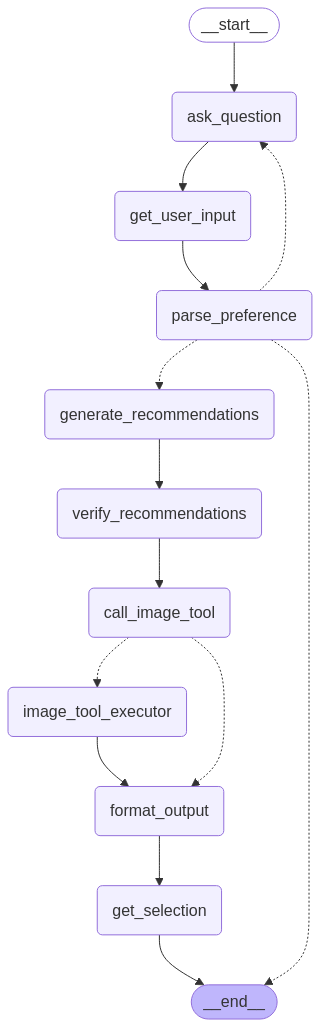

In [16]:
graph_builder = StateGraph(SuggestionState)

graph_builder.add_node("ask_question", ask_question_node)
graph_builder.add_node("get_user_input", human_input_node)
graph_builder.add_node("parse_preference", parse_preference_node)
graph_builder.add_node("generate_recommendations", generate_recommendations_node)
graph_builder.add_node("verify_recommendations", verify_recommendations_node)
graph_builder.add_node("call_image_tool", call_image_tool_node)
graph_builder.add_node("image_tool_executor", ToolNode(suggestion_tools))
graph_builder.add_node("format_output", format_final_output_node)
graph_builder.add_node("get_selection", get_selection_node)

graph_builder.set_entry_point("ask_question")

graph_builder.add_edge("ask_question", "get_user_input")
graph_builder.add_edge("get_user_input", "parse_preference")
graph_builder.add_conditional_edges(
    "parse_preference",
    check_preferences_complete,
    {"ask_question": "ask_question", "generate_recommendations": "generate_recommendations", END: END}
)

graph_builder.add_edge("generate_recommendations", "verify_recommendations")
graph_builder.add_edge("verify_recommendations", "call_image_tool")
graph_builder.add_conditional_edges(
    "call_image_tool",
    route_after_tool_trigger,
    {"image_tool_executor": "image_tool_executor", "format_output": "format_output"}
)
graph_builder.add_edge("image_tool_executor", "format_output")


graph_builder.add_edge("format_output", "get_selection")

graph_builder.add_edge("get_selection", END)

final_suggestion_graph = graph_builder.compile()
print("✅ Suggestion agent graph with integrated selection node compiled successfully.")

try:
    graph_image_bytes = final_suggestion_graph.get_graph().draw_mermaid_png()
    if graph_image_bytes:
        display(Image(graph_image_bytes))
    else:
        print("Graph visualization did not produce an image.")
except Exception as e:
    print(f"\nℹ️ Graph visualization failed. Ensure playwright is installed. Error: {e}")

<div style="background-color:#FFFBEB; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #F59E0B;">
  <h2 style="color:#B45309; border-bottom: 2px solid #D97706; padding-bottom: 5px;">Step 16: Run the Suggestion Agent Graph (Phase 1)</h2>
  <p style="color:gray; margin-top:10px;">
    With the Phase 1 graph compiled, this cell executes the conversational flow for gathering preferences and providing recommendations. The behavior (interactive vs. demo) depends on the <code>INTERACTIVE_MODE</code> flag set in Step 2 and implemented within the graph's nodes (Steps 8 & 13).
  </p>
  <ol style="background-color:#FEFCE8; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #FEF9C3; margin-top:10px; list-style-type: decimal;">
    <li style="color:#713F12; margin-bottom:8px;">
      <strong>Prerequisite Check:</strong> Verifies that the <code>final_suggestion_graph</code> object exists and is compiled.
    </li>
    <li style="color:#713F12; margin-bottom:8px;">
      <strong>User Instructions:</strong> Prints messages explaining the upcoming interaction (primarily relevant in interactive mode).
    </li>
    <li style="color:#713F12; margin-bottom:8px;">
      <strong>Initial State Definition:</strong> Creates the starting <code>initial_state</code> dictionary for the graph, conforming to the <code>SuggestionState</code> TypedDict. It includes a starting human message to kick off the conversation.
    </li>
     <li style="color:#713F12; margin-bottom:8px;">
      <strong>Configuration:</strong> Sets a <code>recursion_limit</code> to prevent infinite loops in the graph execution.
    </li>
     <li style="color:#713F12; margin-bottom:8px;">
      <strong>Invoke Graph:</strong> Calls <code>final_suggestion_graph.invoke(initial_state, config=config)</code>. This starts the execution at the entry point ("ask_question") and runs through the nodes and edges defined previously until an <code>END</code> state is reached (either by user quitting/selecting or an error). <strong>This is where the actual conversation/demo run occurs.</strong>
    </li>
     <li style="color:#713F12; margin-bottom:8px;">
      <strong>Error Handling:</strong> Wraps the invocation in a <code>try...except</code> block to catch potential errors during graph execution, including <code>GraphRecursionError</code> if the step limit is exceeded.
    </li>
     <li style="color:#713F12; margin-bottom:8px;">
      <strong>Final State Summary:</strong> After the graph finishes, it prints a summary of the returned <code>final_state</code>, including:
        <ul>
            <li>Whether the graph finished naturally (<code>is_finished</code>).</li>
            <li>Any captured error messages.</li>
            <li>The final dictionary of collected <code>user_preferences</code>.</li>
            <li>Whether a city was selected for Phase 2 (<code>selected_city_for_phase_2</code>).</li>
            <li>A summary of the final recommendations generated.</li>
            <li>A snippet of the last few messages exchanged.</li>
        </ul>
    </li>
     <li style="color:#713F12;">
      <strong>Prepare for Phase 2:</strong> Extracts the value of <code>selected_city_for_phase_2</code> from the final state into a variable. Prints a message indicating whether the agent is ready to proceed to Phase 2 based on whether a city was successfully selected.
    </li>
  </ol>
  <p style="color:gray; margin-top:10px; font-style: italic;">
   Executing this cell runs the entire Phase 1 process. The output will show the agent's questions, simulated or real user inputs, the final recommendations (including images), and the outcome of the user's selection (or automatic selection in demo mode). The <code>selected_city_for_phase_2</code> variable carries the essential information needed to potentially start Phase 2.
  </p>
</div>

In [17]:
if 'final_suggestion_graph' not in globals() or final_suggestion_graph is None:
    print("ERROR: The 'final_suggestion_graph' is not compiled. Please run the graph definition cell.")
else:
    print("\n--- Starting Travel Suggestion Agent (Structured Flow) ---")
    print("I will ask you about your preferences (vibe, activities, weather, budget).")
    print("Recommendations will be shown, and you will be prompted to select one.")
    print("Type 'q', 'quit', or 'exit' anytime to end.")

    # --- RESET DEMO INDEX BEFORE EACH RUN ---
    if not INTERACTIVE_MODE:
        global demo_answer_index # Declare intention to modify the global variable
        demo_answer_index = 0
        print("🔄 Demo answer index reset to 0 for new run.")
    # --- END RESET ---

    # Initial state
    initial_state = SuggestionState(
        messages=[HumanMessage(content="Hi, I'd like to plan a trip.")],
        user_preferences={},
        text_recommendations=None,
        recommendations=[],
        cities_with_data=[],
        error_message=None,
        is_finished=False,
        selected_city_for_phase_2=None
    )

    config = {"recursion_limit": 150}
    final_state = None

    try:
        # --- Graph Invocation ---
        final_state = final_suggestion_graph.invoke(initial_state, config=config)
        # --- End Invocation ---

        print("\n--- Graph Execution Complete ---")

        if final_state:
             print("\nFinal State Summary:")
             print(f"  - Finished: {final_state.get('is_finished')}")
             print(f"  - Error Message: {final_state.get('error_message')}")
             print(f"  - Collected Preferences: {final_state.get('user_preferences')}")

             # Explicitly show the selection made
             selected_city = final_state.get('selected_city_for_phase_2')
             if selected_city:
                  print(f"  >>> User Selected City for Phase 2: {selected_city} <<<")
             else:
                  print("  >>> User did not select a city (chose quit/refine or error occurred). <<<")

             final_recs = final_state.get('recommendations')
             if final_recs:
                  print(f"  - Displayed {len(final_recs)} Recommendations (check output above).")
             else:
                  print("  - No recommendations generated or stored.")

             final_messages = final_state.get('messages', [])
             if final_messages:
                 print("\nLast few messages in history:")
                 for msg in final_messages[-5:]:
                      if isinstance(msg, AIMessage): print(f"  🤖 Nomad: {msg.content} {f'(Tool Calls: {msg.tool_calls})' if msg.tool_calls else ''}")
                      elif isinstance(msg, HumanMessage): print(f"  👤 You: {msg.content}")
                      elif isinstance(msg, ToolMessage): print(f"  🛠️ Tool Result ({msg.name}): {msg.content}")
                      else: print(f"  System/Other: {type(msg)}")
        else:
             print("Graph execution did not return a final state.")

    except GraphRecursionError:
         print("\n--- ERROR: Conversation ended due to reaching recursion limit ---")
         print(f"The graph exceeded the maximum number of steps ({config['recursion_limit']}).")
         print("This might happen in very long conversations or if there's an unexpected loop.")
    except Exception as e:
        import traceback
        print(f"\n--- An unexpected error occurred during graph execution: {type(e).__name__} ---")
        traceback.print_exc()

    selected_city_for_phase_2 = None
    if final_state and final_state.get('selected_city_for_phase_2'):
        selected_city_for_phase_2 = final_state['selected_city_for_phase_2']
        print(f"\n\n➡️ Ready to proceed to Phase 2 with city: {selected_city_for_phase_2}")
    else:
        print("\n\n⏹️ Phase 1 ended without a city selection for Phase 2.")


--- Starting Travel Suggestion Agent (Structured Flow) ---
I will ask you about your preferences (vibe, activities, weather, budget).
Recommendations will be shown, and you will be prompted to select one.
Type 'q', 'quit', or 'exit' anytime to end.
🔄 Demo answer index reset to 0 for new run.

🤖 Nomad: Okay! What kind of vibe are you going for? (e.g., relaxing, adventurous, romantic, family-friendly, cultural?)
👤 You (Demo Input): I'm looking for a relaxing vibe, maybe somewhere quiet.

🤖 Nomad: Sounds lovely! What kind of activities do you enjoy on a relaxing trip? (e.g., spa treatments, reading by the pool, gentle walks, exploring local cafes?)
👤 You (Demo Input): Mainly spa treatments and maybe some light reading by a pool.

🤖 Nomad: Got it! What kind of weather are you hoping for on this relaxing trip? (e.g., warm and sunny, cool and mild, or something else?)
👤 You (Demo Input): I definitely prefer warm and sunny weather.

🤖 Nomad: Warm and sunny it is! And what's your general budg

🤖 Demo Mode: Automatically selecting first valid city: Ubud

--- Graph Execution Complete ---

Final State Summary:
  - Finished: True
  - Error Message: None
  - Collected Preferences: {'vibe': 'relaxing vibe, maybe somewhere quiet', 'activities': 'spa treatments and light reading by a pool', 'weather': 'warm and sunny', 'budget': 'mid-range to luxury'}
  >>> User Selected City for Phase 2: Ubud <<<
  - Displayed 3 Recommendations (check output above).

Last few messages in history:
  🤖 Nomad: Okay, I've generated recommendations based on your preferences. Let me quickly fetch some images... (Tool Calls: [{'name': 'unsplash_get_image', 'args': {'city': 'Ubud', 'country': 'Indonesia'}, 'id': 'unsplash_get_image_0_Ubud', 'type': 'tool_call'}, {'name': 'unsplash_get_image', 'args': {'city': 'Sedona', 'country': 'USA'}, 'id': 'unsplash_get_image_1_Sedona', 'type': 'tool_call'}, {'name': 'unsplash_get_image', 'args': {'city': 'Marrakech', 'country': 'Morocco'}, 'id': 'unsplash_get_image_2_

<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 17: Define Weather Fetching Tool (OpenWeatherMap)</h2>
  <p style="color:gray; margin-top:10px;">
    To provide current conditions for the user's selected city in Phase 2, we define a tool to fetch live weather data. This uses the OpenWeatherMap API and includes a robust fallback mechanism.
  </p>
  <ul style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: square;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Placeholder Function (<code>get_placeholder_weather</code>):</strong>
        <ul>
            <li>Defines a helper function that generates randomized, clearly marked placeholder weather data (temperature, condition, humidity).</li>
            <li>This function is called by the main tool if the API key is missing or if any error occurs during the live API call, ensuring the agent can always provide some weather-related information.</li>
        </ul>
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Weather Tool Function (<code>get_weather</code> @tool):</strong>
        <ul>
            <li>The main function, decorated with LangChain's <code>@tool</code> decorator, making it a callable tool within the LangChain ecosystem (even though it's called directly in the current Phase 2 implementation).</li>
            <li>Accepts <code>city</code> and optional <code>country</code> arguments.</li>
            <li>Retrieves the <code>OPENWEATHERMAP_API_KEY</code> from environment variables (set in Step 2).</li>
            <li>If the key is missing, it prints a debug message and immediately returns data from <code>get_placeholder_weather</code>.</li>
            <li>If the key exists, it constructs the API request URL for OpenWeatherMap's current weather endpoint, including the city/country query and metric units.</li>
            <li>Uses the <code>requests</code> library to make the API call with a timeout.</li>
            <li>Includes comprehensive error handling for timeouts, HTTP errors (like 404 Not Found, 401 Invalid Key), general request exceptions, and unexpected errors. In all error cases, it falls back to returning placeholder data.</li>
            <li>If the API call is successful (HTTP 200) and returns valid data, it parses the JSON response, extracts relevant fields (location, temperature, condition, humidity, etc.), filters out any null values, and returns the weather information as a dictionary.</li>
        </ul>
    </li>
     <li style="color:#1E3A8A;">
      <strong>Tool List for Phase 2 (<code>phase2_tools</code>):</strong>
        <ul>
            <li>The <code>get_weather</code> tool is added to a list named <code>phase2_tools</code>. While the current Phase 2 implementation calls this tool directly via Python code rather than through LLM-triggered function calling, this list structure is maintained, potentially for future flexibility or reflecting an earlier design iteration.</li>
        </ul>
    </li>
  </ul>
</div>

In [18]:
def get_placeholder_weather(city: str, country: Optional[str] = "Unknown") -> Dict[str, Any]:
     """Generates random placeholder weather data."""
     return {
        "location": f"{city}, {country or 'Unknown'} (Placeholder)",
        "temperature_celsius": round(random.uniform(5, 30), 1),
        "condition": random.choice(["Sunny", "Partly Cloudy", "Cloudy", "Light Rain", "Clear Sky"]),
        "humidity_percent": random.randint(30, 85),
        "comment": "Weather data is placeholder.",
        "fetched_at": datetime.datetime.now().isoformat()
    }

@tool
def get_weather(city: str, country: Optional[str] = None) -> Dict[str, Any]:
    """
    Fetches the current weather for a given city using the OpenWeatherMap API.
    Country is optional but helps accuracy. Returns placeholder data if API key is missing or call fails.
    Example: get_weather(city='London', country='UK')
    """
    api_key = os.environ.get("OPENWEATHERMAP_API_KEY")

    # print(f"\n--- DEBUG: get_weather called with city='{city}', country='{country}' ---")

    if not api_key:
        print("DEBUG: OpenWeatherMap API Key not found in environment. Returning placeholder.")
        return get_placeholder_weather(city, country)

    try:
        base_url = "http://api.openweathermap.org/data/2.5/weather?"
        query_param = city
        if country:
             query_param += f",{country}"

        complete_url = f"{base_url}appid={api_key}&q={query_param}&units=metric"

        response = requests.get(complete_url, timeout=10)
        response.raise_for_status()
        data = response.json()

        if data.get("cod") == 200:
            main = data.get("main", {})
            weather_desc = data.get("weather", [{}])[0].get("description", "N/A")
            weather_info = {
                "location": f"{data.get('name', city)}, {data.get('sys', {}).get('country', country or 'N/A')}",
                "temperature_celsius": main.get("temp"),
                "feels_like_celsius": main.get("feels_like"),
                "humidity_percent": main.get("humidity"),
                "condition": weather_desc.capitalize(),
                "wind_speed_mps": data.get("wind", {}).get("speed"),
                "fetched_at": datetime.datetime.now().isoformat()
            }
            weather_info_filtered = {k: v for k, v in weather_info.items() if v is not None}
            return weather_info_filtered
        else:
            error_message = data.get("message", "Unknown API error")
            return get_placeholder_weather(city, country)

    except requests.exceptions.Timeout:
         print(f"DEBUG: Timeout connecting to OpenWeatherMap for '{query_param}'. Returning placeholder.")
         return get_placeholder_weather(city, country)
    except requests.exceptions.HTTPError as http_err:
         print(f"DEBUG: HTTP error during OpenWeatherMap call for '{query_param}': {http_err}. Returning placeholder.")
         return get_placeholder_weather(city, country)
    except requests.exceptions.RequestException as req_err:
        print(f"DEBUG: Network error during OpenWeatherMap call for '{query_param}': {req_err}. Returning placeholder.")
        return get_placeholder_weather(city, country)
    except Exception as e:
        import traceback
        print(f"DEBUG: Unexpected error fetching weather for '{query_param}': {e}.")
        traceback.print_exc()
        return get_placeholder_weather(city, country)

phase2_tools = [get_weather]
print(f"Weather tool '{get_weather.name}' defined and ready for Phase 2.")

Weather tool 'get_weather' defined and ready for Phase 2.


<div style="background-color:#F0FDF4; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #22C55E;">
  <h2 style="color:#15803D; border-bottom: 2px solid #16A34A; padding-bottom: 5px;">Step 18: Define RAG Document Retrieval Function</h2>
  <p style="color:gray; margin-top:10px;">
    This function encapsulates the core logic for the Retrieval-Augmented Generation (RAG) process. It takes a city name and user preferences and retrieves the most relevant Point of Interest (POI) documents from the ChromaDB vector store prepared earlier.
  </p>
  <ul style="background-color:#ECFDF5; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #D1FAE5; margin-top:10px; list-style-type: square;">
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Function Signature:</strong> Accepts the target <code>city</code>, a dictionary of <code>preferences</code> (which can also contain the user's question during Q&A), the ChromaDB <code>collection</code> object, the query <code>embedder</code> function instance, and the desired number of results (<code>n_results</code>).
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Input Validation:</strong> Performs initial checks to ensure the embedder, collection, city, and preferences are provided and valid, returning an empty list if not.
    </li>
     <li style="color:#065F46; margin-bottom:8px;">
        <strong>Query Construction:</strong> Creates a natural language query string (<code>query_text</code>) combining the city and the user's preferences/question (e.g., "Points of interest in Marrakech suitable for someone interested in [vibe: relaxing, activities: spa]").
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Query Embedding:</strong>
        <ul>
            <li>Calls the provided <code>embedder</code> function (the <code>GeminiEmbeddingFunctionChroma</code> instance with <code>task_type="retrieval_query"</code>) to convert the <code>query_text</code> into a vector embedding using the Gemini API.</li>
            <li>Includes checks to ensure the embedder returns a valid list containing a non-empty embedding vector.</li>
             <li>Handles potential NumPy array format from some embedders by converting to a standard list of floats.</li>
        </ul>
    </li>
     <li style="color:#065F46; margin-bottom:8px;">
      <strong>ChromaDB Query:</strong>
        <ul>
            <li>Calls the <code>collection.query()</code> method of the ChromaDB collection object.</li>
            <li>Passes the generated <code>query_vector</code> to find documents with similar embeddings.</li>
            <li>Specifies <code>n_results</code> to limit the number of documents returned.</li>
            <li>Crucially, uses a <code>where={"city": city}</code> filter. This ensures that the similarity search is restricted *only* to documents belonging to the specified city, preventing irrelevant results from other locations even if their descriptions are similar.</li>
        </ul>
    </li>
      <li style="color:#065F46; margin-bottom:8px;">
      <strong>Result Extraction:</strong> Extracts the actual document text content from the <code>'documents'</code> field of the ChromaDB query response.
    </li>
     <li style="color:#065F46;">
      <strong>Error Handling:</strong> Wraps the embedding and query process in a <code>try...except</code> block to catch potential errors during API calls or database interaction, returning an empty list upon failure.
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    This function is called during Phase 2 to fetch relevant POI context before generating the detailed city description, and again during the Q&A loop to find context relevant to the user's specific questions. The quality of the RAG results heavily depends on the effectiveness of the query embedding and the content of the indexed documents.
  </p>
</div>

In [19]:
def retrieve_rag_documents(
    city: str,
    preferences: Dict[str, Any],
    collection: Optional[chromadb.Collection],
    embedder: Optional[EmbeddingFunction],
    n_results: int = 5
) -> List[str]:
    """
    Retrieves relevant POI documents from the ChromaDB collection based on city and preferences.
    Handles potential numpy array embeddings and provides more robust checks.
    """

    if embedder is None:
        print("RAG Error: Query embedding function (embedder) is not available.")
        return []
    if collection is None:
        print("RAG Error: ChromaDB collection is not available.")
        return []
    if not city or not isinstance(city, str):
        print(f"RAG Error: Invalid city provided: {city}")
        return []
    if not preferences or not isinstance(preferences, dict):
         print(f"RAG Error: Invalid preferences provided: {preferences}")
         return []

    pref_list = [f"{k}: {v}" for k, v in preferences.items() if v]
    pref_string = ", ".join(pref_list)
    query_text = f"Points of interest in {city} suitable for someone interested in [{pref_string}]"

    try:
        query_embedding_list = embedder([query_text])
        if not isinstance(query_embedding_list, list) or len(query_embedding_list) < 1:
            print(f"RAG Error: Embedder returned invalid result type or empty list. Result: {query_embedding_list}")
            return []

        query_vector_obj = query_embedding_list[0]
        if not hasattr(query_vector_obj, '__len__') or len(query_vector_obj) == 0:
             print(f"RAG Error: Extracted embedding vector is invalid or empty. Vector Type: {type(query_vector_obj)}. Vector: {query_vector_obj}")
             return []

        if isinstance(query_vector_obj, np.ndarray):
            query_vector = [float(x) for x in query_vector_obj]
        else:
            query_vector = [float(x) for x in query_vector_obj]

        results = collection.query(
            query_embeddings=[query_vector],
            n_results=n_results,
            where={"city": city},
        )

        retrieved_docs = []
        if results and isinstance(results.get('documents'), list) and len(results['documents']) > 0:
            retrieved_docs = results['documents'][0]
            
        return retrieved_docs

    except Exception as e:
        print(f"An error occurred during RAG retrieval or embedding check: {e}")
        traceback.print_exc()
        return []

print("Function 'retrieve_rag_documents' defined.")

Function 'retrieve_rag_documents' defined.


<div style="background-color:#F0FDF4; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #22C55E;">
  <h2 style="color:#15803D; border-bottom: 2px solid #16A34A; padding-bottom: 5px;">Step 19: Define Phase 2 LLM, Data Structures & Config</h2>
  <p style="color:gray; margin-top:10px;">
    This cell sets up the core configurations for Phase 2, where the agent provides detailed city information. It defines the specific Gemini model, the Pydantic data structures for the output, and the Grounding tool configuration for the Phase 2 LLM.
  </p>
  <ul style="background-color:#ECFDF5; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #D1FAE5; margin-top:10px; list-style-type: square;">
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Phase 2 Model Name:</strong> Sets the <code>PHASE2_MODEL_NAME</code> variable, specifying the LLM to be used for generating the detailed city overview.
    </li>
    <li style="color:#065F46; margin-bottom:8px;">
      <strong>Phase 2 Data Models (Pydantic):</strong> Defines the schemas for the structured output:
        <ul>
            <li><code>PointOfInterest</code>: Structure for POIs (description generated via RAG context).</li>
            <li><code>CityEvent</code>: Structure for events (found via Grounding).</li>
            <li><code>CityInformation</code>: The main model aggregating city info, POIs, events, and a weather placeholder.</li>
        </ul>
    </li>
     <li style="color:#065F46; margin-bottom:8px;">
        <strong>Configure Grounding Tool (Google Search):</strong>
        <ul>
            <li>Creates the <code>search_tool</code> and adds it to the <code>phase2_tools_genai</code> list. This enables the Phase 2 LLM to use Google Search internally for event discovery.</li>
        </ul>
    </li>
    <li style="color:#065F46;">
      <strong>Define Target Output Schema:</strong>
        <ul>
            <li>Generates the <code>phase2_output_schema</code> JSON string from the <code>CityInformation</code> model. This schema instructs the LLM on the desired output format (excluding weather). Includes error handling.</li>
        </ul>
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    With the model, output structures, and Grounding tool configured, the next step is to define the system prompt that will guide this Phase 2 LLM.
  </p>
</div>

In [20]:
PHASE2_MODEL_NAME = "gemini-2.0-flash"
print(f"Phase 2 Model Name set to: {PHASE2_MODEL_NAME}")

class PointOfInterest(BaseModel):
    name: str = Field(description="Name of the Point of Interest.")
    type: str = Field(description="Category or type of the POI (e.g., Museum, Park, Restaurant, Temple, Market).")
    description: str = Field(description="A brief (1-2 sentence) description of the POI, highlighting its relevance to user preferences based on provided context.")

class CityEvent(BaseModel):
    name: str = Field(description="Name of the event.")
    summary: str = Field(description="A short (1 sentence) summary of the event.")

class CityInformation(BaseModel):
    city_name: str = Field(description="The name of the selected city.")
    country_name: str = Field(description="The name of the country.")
    general_summary: str = Field(description="A general introductory paragraph (2-4 sentences) about the city, tailored to the user's vibe/preferences.")
    weather_summary: str = Field(description="A concise summary (1-2 sentences) of the current weather. This will be added *after* the LLM call.")
    points_of_interest: List[PointOfInterest] = Field(description="A list of 3-5 relevant Points of Interest based on RAG context and user preferences.")
    events: List[CityEvent] = Field(description="A list of 2-4 current or upcoming events found via grounding.")

search_tool = genai_types.Tool(google_search=genai_types.GoogleSearch())
phase2_tools_genai = [search_tool]
print(f"Defined google.genai tools for Phase 2: Grounding ONLY")

phase2_output_schema = None
try:
    if 'CityInformation' not in globals(): raise NameError("CityInformation Pydantic model not defined.")
    print(f"Phase 2 LLM will be prompted to output JSON conforming to '{CityInformation.__name__}' schema (excluding weather initially).")
    phase2_output_schema = CityInformation.schema_json(indent=2)
except NameError as ne:
     print(f"ERROR: Cannot prepare output schema - {ne}. Structured output may fail.")
except Exception as e:
     print(f"ERROR preparing output schema: {e}")

Phase 2 Model Name set to: gemini-2.0-flash
Defined google.genai tools for Phase 2: Grounding ONLY
Phase 2 LLM will be prompted to output JSON conforming to 'CityInformation' schema (excluding weather initially).


<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 20: Define Phase 2 System Prompt</h2>
  <p style="color:gray; margin-top:10px;">
    This cell constructs the detailed system prompt that will guide the Gemini LLM during Phase 2 when it generates the structured city information. This prompt is critical for ensuring the LLM understands its role, inputs, tasks, and output requirements.
  </p>
  <ul style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: square;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Prerequisite Check:</strong> Ensures the <code>phase2_output_schema</code> string (generated in the previous step) is available before constructing the prompt that embeds it.
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>LLM Role & Goal:</strong> Clearly defines the LLM's persona ("specialized travel information assistant") and its objective (provide a detailed overview based on preferences, RAG, and grounding).
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
        <strong>Expected Inputs:</strong> Explicitly tells the LLM what information it will receive: selected city, user preferences summary, and the retrieved RAG context (POI data).
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
        <strong>Tasks Defined:</strong> Breaks down the LLM's responsibilities:
        <ul>
            <li>Use <strong>Grounding</strong> (Google Search) to find 2-4 notable current/upcoming events.</li>
            <li>Analyze the provided <strong>RAG context</strong> to select 3-5 relevant POIs matching user preferences.</li>
            <li>Synthesize this information into the specified JSON structure.</li>
            <li>Explicitly instructs the LLM **not** to include weather information itself.</li>
        </ul>
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Strict Output Requirements:</strong>
        <ul>
            <li>Emphasizes that the output MUST be **only** a single, valid JSON object conforming exactly to the provided schema.</li>
            <li>Injects the <code>phase2_output_schema</code> string directly into the prompt so the LLM knows the target structure.</li>
            <li>Provides field-level guidance (e.g., write a compelling summary, use RAG context for POI descriptions, use grounding for events, OMIT weather_summary).</li>
        </ul>
    </li>
      <li style="color:#1E3A8A;">
      <strong>Example Thought Process:</strong> Includes a brief example to illustrate how the LLM should internally plan its actions (use grounding, select from RAG, construct JSON without weather).
    </li>
  </ul>
</div>

In [21]:
if 'phase2_output_schema' not in globals() or phase2_output_schema is None:
    print("ERROR: 'phase2_output_schema' not found. Cannot define prompt correctly.")
    phase2_system_prompt = "ERROR: Schema missing."
else:
    phase2_system_prompt = f"""You are a specialized travel information assistant. Your goal is to provide a detailed, helpful, and engaging overview of a selected city based on user preferences, retrieved local Points of Interest (POIs), and recent events found via grounding.

**User Input:**
You will receive:
1. The selected city name.
2. A summary of the user's preferences (vibe, activities, weather, budget).
3. Context containing relevant Points of Interest (POIs) retrieved from a database for the selected city.

**Your Tasks:**

1.  **Events:** Use your grounding capabilities (Google Search) to find 2-4 relevant current or upcoming notable events (like festivals, major concerts, exhibitions, significant local happenings) in the `selected city`. Do NOT just list generic activities.
2.  **RAG POI Selection:** Analyze the provided `Context POIs`. Select 3-5 diverse POIs that BEST match the user's `preferences`. Prioritize POIs mentioned in the context.
3.  **Generate Content:** Synthesize the gathered information (preferences, RAG POIs, grounded events) into a structured JSON output. **DO NOT include weather information in your response.**

**Output Requirements:**

*   **Strict JSON:** You MUST output ONLY a single, valid JSON object conforming exactly to the following schema, **excluding the 'weather_summary' field**. Do NOT include any introductory text, explanations, apologies, or closing remarks outside the JSON structure.
*   **Schema (Target Structure - You will omit weather_summary):**
    ```json
    {phase2_output_schema}
    ```
*   **Field Details:**
    *   `city_name`, `country_name`: Fill accurately based on input.
    *   `general_summary`: Write a compelling 2-4 sentence paragraph introducing the city, connecting it to the user's general `vibe` and `preferences`.
    *   `weather_summary`: **<<< OMIT THIS FIELD FROM YOUR JSON OUTPUT >>>**
    *   `points_of_interest`: Populate the list using the POIs you selected from the `RAG context` that match user `preferences`. Ensure the `name`, `type`, and `description` fields are filled based *only* on the provided RAG context. The description should briefly mention why it fits the preferences.
    *   `events`: Populate the list using the current/upcoming events found via `grounding`. Provide a concise name and summary for each.

**Example Internal Thought Process:**
1. Receive Input: City="Paris", Prefs={{'vibe':'romantic', 'activities':'museums', 'budget':'mid-range'}}, RAG Context=[POI data...].
2. Tool Call Planning: Need to use grounding for events. *No weather tool call needed*.
3. Generate Final Response (using Grounding internally for events): Construct the JSON output (WITHOUT weather_summary), selecting relevant museums from RAG context for the POI list, finding events like "Louvre Late Nights" via grounding for the events list, and writing the summary paragraphs.
"""
print("Phase 2 System Prompt updated.")

Phase 2 System Prompt updated.


<div style="background-color:#EFF6FF; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #3B82F6;">
  <h2 style="color:#1E40AF; border-bottom: 2px solid #2563EB; padding-bottom: 5px;">Step 21: Define Phase 2 Orchestration Function</h2>
  <p style="color:gray; margin-top:10px;">
    This function, <code>execute_phase2</code>, orchestrates the entire process of gathering and synthesizing detailed information for the user's selected city. It brings together RAG, external tool calls (weather), and a Grounding-enabled LLM call to generate the final structured output.
  </p>
  <ol style="background-color:#DBEAFE; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #BFDBFE; margin-top:10px; list-style-type: decimal;">
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Inputs:</strong> Takes the <code>selected_city</code> name, the dictionary of user <code>preferences</code>, and the optional <code>country</code> name.
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
        <strong>Prerequisite Checks:</strong> Performs extensive checks at the beginning to ensure all required global variables and functions (like the Gemini <code>client</code>, ChromaDB <code>poi_collection</code>, RAG/Weather functions, system prompt, Pydantic model, etc.) are available and valid. This prevents runtime errors if setup steps failed or were skipped. Crucially checks if the Gemini <code>client</code> was initialized (dependent on the API key).
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Step 1: RAG Retrieval:</strong> Calls the <code>retrieve_rag_documents</code> function (defined in Step 19) to fetch relevant POI documents from ChromaDB based on the city and user preferences. Formats these documents into a <code>rag_context</code> string to be included in the LLM prompt. Handles potential errors during retrieval.
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Step 2: Fetch Weather Data:</strong> Calls the <code>get_weather</code> tool function (defined in Step 17) directly using Python code (<code>get_weather.invoke(...)</code>). This fetches live weather data (or placeholder data if the API key/call fails) *before* calling the main LLM. Parses the result into a user-friendly <code>weather_summary_str</code>.
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Step 3: Construct LLM Input:</strong> Assembles the input for the Phase 2 LLM:
        <ul>
            <li>Creates a summary of user preferences.</li>
            <li>Constructs the main user request content, including the selected city, preference summary, and the retrieved <code>rag_context</code>.</li>
            <li>Combines the detailed <code>phase2_system_prompt</code> (from Step 20) with this user request content into the format expected by the <code>client.models.generate_content</code> method.</li>
        </ul>
    </li>
    <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Step 4: Call Phase 2 LLM (with Grounding):</strong>
        <ul>
            <li>Invokes the Gemini LLM using <code>client.models.generate_content</code>.</li>
            <li>Passes the constructed input history and the <code>PHASE2_MODEL_NAME</code>.</li>
            <li>Crucially, enables Grounding by providing the <code>phase2_tools_genai</code> list (containing the Google Search tool) in the <code>GenerateContentConfig</code>. The LLM uses this internally to find events.</li>
            <li>Includes error handling for Google API errors during the call.</li>
        </ul>
    </li>
     <li style="color:#1E3A8A; margin-bottom:8px;">
      <strong>Step 5: Process LLM Response:</strong> Extracts the generated text content from the LLM's response. Includes checks for missing candidates or text parts.
    </li>
     <li style="color:#1E3A8A;">
      <strong>Step 6: Parse JSON, Add Weather, & Validate:</strong>
        <ul>
            <li>Cleans the extracted LLM text (removing potential markdown code fences).</li>
            <li>Parses the cleaned text as JSON, expecting it to match the <code>CityInformation</code> structure (minus weather).</li>
            <li>If parsing is successful, it **injects** the previously fetched <code>weather_summary_str</code> into the parsed dictionary.</li>
            <li>Attempts to validate the combined dictionary against the full <code>CityInformation</code> Pydantic model for final verification. If validation fails, it prints a warning but still returns the parsed (but unvalidated) dictionary.</li>
            <li>Returns the final, validated (or partially validated) dictionary containing all city details. Includes error handling for JSON parsing and validation.</li>
        </ul>
    </li>
  </ul>
  <p style="color:gray; margin-top:10px; font-style: italic;">
    This function acts as the main engine for Phase 2, coordinating data retrieval (RAG, weather tool) and generative synthesis (LLM with Grounding) to produce a rich, structured overview of the selected travel destination.
  </p>
</div>

In [22]:
def execute_phase2(
    selected_city: str,
    preferences: Dict[str, Any],
    country: Optional[str] = None
    ) -> Optional[Dict[str, Any]]:
    """
    Orchestrates Phase 2: Retrieves RAG context, calls the Phase 2 LLM
    with grounding ONLY, calls weather
    tool separately, parses the structured JSON response, adds weather, and returns
    the final city information dictionary.
    """

    if not selected_city:
        print("Phase 2 Error: No city was selected.")
        return None
    required_globals = {
        'client': client,
        'poi_collection': poi_collection,
        'gemini_embedder_query': gemini_embedder_query,
        'phase2_tools_genai': phase2_tools_genai,
        'phase2_system_prompt': phase2_system_prompt,
        'get_weather': get_weather,
        'PHASE2_MODEL_NAME': PHASE2_MODEL_NAME,
        'retrieve_rag_documents': retrieve_rag_documents,
        'CityInformation': CityInformation
    }
    for req_var_name, req_var_value in required_globals.items():
         if req_var_name not in globals() or req_var_value is None:
              print(f"Phase 2 Error: Required component '{req_var_name}' is not available or is None.")
              return None
         if req_var_name in ['get_weather', 'retrieve_rag_documents'] and not callable(req_var_value):
             print(f"Phase 2 Error: Required function '{req_var_name}' is not callable.")
             return None
         if req_var_name == 'CityInformation' and not issubclass(req_var_value, BaseModel):
             print(f"Phase 2 Error: Required Pydantic model '{req_var_name}' is not valid.")
             return None


    # 1. RAG Retrieval
    rag_docs = []
    try:
        rag_docs = retrieve_rag_documents(
            city=selected_city,
            preferences=preferences,
            collection=poi_collection,
            embedder=gemini_embedder_query,
            n_results=5
        )
        if rag_docs:
            rag_context = "\n\n".join([f"Context POI {i+1}:\n{doc}" for i, doc in enumerate(rag_docs)])
        else:
            rag_context = "No relevant Points of Interest found in the database for this city and preferences."
            print("Phase 2 RAG: No documents retrieved (or function returned empty).")
    except Exception as rag_err:
        print(f"Phase 2 RAG: Error during retrieval: {rag_err}")
        traceback.print_exc()
        rag_context = "Error retrieving Points of Interest from the database."


    # 2. Call Weather Tool Separately
    weather_summary_str = "Weather information currently unavailable."
    try:
        weather_input = {"city": selected_city}
        if country:
            weather_input["country"] = country
        weather_data = get_weather.invoke(weather_input)

        if weather_data and isinstance(weather_data, dict):
             temp = weather_data.get('temperature_celsius')
             cond = weather_data.get('condition', 'N/A')
             loc = weather_data.get('location', selected_city)
             feels = weather_data.get('feels_like_celsius')

             weather_parts = []
             if temp is not None: weather_parts.append(f"{temp}°C")
             if cond != 'N/A': weather_parts.append(f"{cond}")
             summary_core = " and ".join(filter(None, weather_parts))
             if not summary_core: summary_core = "condition unavailable"

             weather_summary_str = f"Currently it is {summary_core} in {loc}."
             if feels is not None:
                 weather_summary_str += f" Feels like {feels}°C."
        else:
             print("Phase 2 Weather: Tool returned no data or unexpected format.")

    except Exception as weather_e:
        print(f"Phase 2 Weather: Error calling get_weather tool: {weather_e}")
        traceback.print_exc()


    #  3. Construct Input History for LLM
    pref_summary = ", ".join([f"{k}: {v}" for k, v in preferences.items() if v])
    user_content = f"""
Selected City: {selected_city} {f"({country})" if country else ""}
User Preferences Summary: [{pref_summary}]

Retrieved Points of Interest Context:
---
{rag_context}
---

Please generate the detailed city information (excluding weather) based on all instructions in the system prompt. Output only the valid JSON object.
"""
    initial_user_part_text = f"""SYSTEM PROMPT:
---
{phase2_system_prompt}
---

USER REQUEST:
---
{user_content}"""

    current_content_history = [
        genai_types.Content(role="user", parts=[genai_types.Part(text=initial_user_part_text)])
    ]

    # 4. Call Phase 2 LLM
    generated_text = None
    try:
        content_config_with_grounding = genai_types.GenerateContentConfig(
            tools=phase2_tools_genai
        )

        response = client.models.generate_content(
            model=PHASE2_MODEL_NAME,
            contents=current_content_history,
            config=content_config_with_grounding
        )

        # 5. Process Final LLM Response 
        if not response.candidates:
             print("Phase 2 Error: LLM response missing candidates.")
             return None

        if not (response.candidates[0].content.parts and hasattr(response.candidates[0].content.parts[0], 'text')):
             print("Phase 2 Error: LLM response did not contain expected text part.")
             try: print(f"LLM Raw Response: {response}")
             except Exception: pass
             return None

        generated_text = response.candidates[0].content.parts[0].text

    except google.api_core.exceptions.GoogleAPIError as api_error:
        print(f"Phase 2 Error: Google API Error during generate_content: {api_error}")
        if hasattr(api_error, 'message'): print(f"API Error Message: {api_error.message}")
        return None
    except Exception as llm_call_err:
        print(f"An unexpected error occurred during Phase 2 LLM call: {type(llm_call_err).__name__} - {llm_call_err}")
        traceback.print_exc()
        return None

    #6. Parse JSON, Add Weather, & Validate
    if generated_text:
        parsed_data = None
        try:
            text_to_parse = generated_text.strip()
            if text_to_parse.startswith("```json"):
                text_to_parse = text_to_parse[7:]
                if text_to_parse.endswith("```"):
                    text_to_parse = text_to_parse[:-3]
            elif text_to_parse.startswith("```"):
                 text_to_parse = text_to_parse[3:]
                 if text_to_parse.endswith("```"):
                    text_to_parse = text_to_parse[:-3]
            text_to_parse = text_to_parse.strip()

            if not text_to_parse:
                 raise ValueError("LLM returned empty text after cleaning.")

            parsed_data = json.loads(text_to_parse)

            if isinstance(parsed_data, dict):
                parsed_data['weather_summary'] = weather_summary_str
            else:
                print("Warning: LLM response parsed but was not a dictionary. Cannot add weather.")
                return None

            try:
                 city_info = CityInformation(**parsed_data)
                 return city_info.dict()
            except Exception as pydantic_error:
                 print(f"Phase 2 Warning: Combined data failed Pydantic validation: {pydantic_error}")
                 print(f"Data that failed validation: {parsed_data}")
                 return parsed_data

        except json.JSONDecodeError as json_error:
            print(f"Phase 2 Error: Failed to decode LLM response as JSON: {json_error}")
            print(f"LLM Raw Output (before cleaning) was:\n---\n{generated_text}\n---")
            return None
        except Exception as parse_validate_error:
            print(f"Phase 2 Error: Error during JSON processing or validation: {parse_validate_error}")
            if generated_text: print(f"LLM Raw Output was:\n---\n{generated_text}\n---")
            traceback.print_exc()
            return None
    else:
        print("Phase 2 Error: No text generated by the LLM.")
        return None
print("Phase 2 execution logic function.")

Phase 2 execution logic function.


<div style="background-color:#FFFBEB; padding:15px; border-radius:8px; margin-top:20px; border:1px dashed #F59E0B;">
  <h2 style="color:#B45309; border-bottom: 2px solid #D97706; padding-bottom: 5px;">Step 22: Execute Phase 2 & Initiate Q&A Session</h2>
  <p style="color:gray; margin-top:10px;">
    This cell executes the second phase of the agent's workflow if a city was successfully selected in Phase 1. It calls the <code>execute_phase2</code> function to generate detailed city information and then initiates an interactive or demo-driven Question & Answer session about that city, depending on the <code>INTERACTIVE_MODE</code> flag.
  </p>
  <ol style="background-color:#FEFCE8; padding:10px 10px 10px 30px; border-radius:6px; border:1px solid #FEF9C3; margin-top:10px; list-style-type: decimal;">
    <li style="color:#713F12; margin-bottom:8px;">
      <strong>Check Phase 1 Outcome:</strong> Examines the <code>final_state</code> from the Phase 1 graph execution (Step 16) to see if a city was selected via <code>selected_city_for_phase_2</code>.
    </li>
     <li style="color:#713F12; margin-bottom:8px;">
      <strong>Prepare for Phase 2:</strong> If a city was selected, retrieves necessary details (city name, prefs, image, country) and sets the <code>proceed_to_phase2</code> flag. Otherwise, prints a message indicating Phase 2 cannot start.
    </li>
    <li style="color:#713F12; margin-bottom:8px;">
      <strong>Execute Phase 2 Logic:</strong> If <code>proceed_to_phase2</code> is <code>True</code>, calls the <code>execute_phase2</code> function (defined in Step 21) to trigger RAG, weather fetch, and the Grounding-enabled LLM call. Includes error handling.
    </li>
     <li style="color:#713F12; margin-bottom:8px;">
      <strong>Display Detailed City Information:</strong> If Phase 2 execution is successful and returns data (<code>city_info_dict</code>), extracts the details and renders a rich HTML overview of the city, including summary, weather, POIs, and events.
     </li>
     <li style="color:#713F12; margin-bottom:8px;">
      <strong>Initiate Q&A Session:</strong> If city information was displayed, prepares context strings (summary of displayed POIs/events) and proceeds to the Q&A section.
    </li>
    <li style="color:#713F12; margin-bottom:8px;">
        <strong>Q&A Loop Logic (Handles Interaction Mode):</strong>
        <ul>
            <li><strong>If <code>INTERACTIVE_MODE</code> is <code>True</code>:</strong> Enters a <code>while True</code> loop, prompts the user for questions using <code>input()</code>, and handles 'quit' commands.</li>
            <li><strong>If <code>INTERACTIVE_MODE</code> is <code>False</code> (Demo Mode):</strong> Defines a list of predefined <code>demo_questions</code> (dynamically based on retrieved POIs/events if possible) and iterates through them using a <code>for</code> loop, limited by <code>MAX_DEMO_QUESTIONS</code>.</li>
            <li><strong>For Each Question (Both Modes):</strong>
                <ul>
                  <li>Performs RAG by calling <code>retrieve_rag_documents</code> based on the current question.</li>
                  <li>Constructs a detailed prompt for the Q&A LLM, including context about previously shown info, RAG snippets, and the question itself.</li>
                  <li>Checks if the Gemini <code>client</code> is available (handles missing API key). If available, calls the Q&A LLM (<code>gemini-1.5-flash-latest</code>).</li>
                  <li>Extracts, formats (HTML), and displays the LLM's answer.</li>
                  <li>Includes error handling for each Q&A turn.</li>
                </ul>
            </li>
        </ul>
    </li>
     <li style="color:#713F12;">
        <strong>Handle Phase 2 Failure:</strong> If <code>proceed_to_phase2</code> was true but <code>execute_phase2</code> failed (<code>city_info_dict</code> is None), prints an informative error message.
    </li>
  </ol>
  <p style="color:gray; margin-top:10px; font-style: italic;">
   This final cell integrates Phase 1 and Phase 2. It displays the detailed city information generated via RAG and Grounding, and then runs a Q&A loop allowing follow-up questions answered using RAG context. The Q&A behavior adapts based on the <code>INTERACTIVE_MODE</code> flag for evaluation purposes.
  </p>
</div>

In [23]:
selected_city = None
user_prefs = {}
selected_city_img_url = PLACEHOLDER_IMAGE_URL
selected_city_country = None
proceed_to_phase2 = False
city_info_dict = None

if 'final_state' in globals() and final_state and isinstance(final_state, dict) and final_state.get('selected_city_for_phase_2'):
    selected_city = final_state['selected_city_for_phase_2']
    user_prefs = final_state.get('user_preferences', {})
    print(f"✅ Proceeding to Phase 2 for selected city: {selected_city}")

    phase1_recs = final_state.get('recommendations', [])
    if isinstance(phase1_recs, list):
        for rec in phase1_recs:
            if isinstance(rec, dict) and rec.get('city') == selected_city:
                selected_city_img_url = rec.get('image_url', PLACEHOLDER_IMAGE_URL)
                selected_city_country = rec.get('country')
                break

    proceed_to_phase2 = True
else:
    print("⏹️ Phase 2 cannot start: No valid city selected in Phase 1 or 'final_state' missing/invalid.")
    if 'final_state' in globals() and isinstance(final_state, dict):
        print(f"   Phase 1 Final state details: Finished={final_state.get('is_finished')}, Error={final_state.get('error_message')}, Selection={final_state.get('selected_city_for_phase_2')}")

if proceed_to_phase2:
    print(f"\n--- Executing Phase 2 for {selected_city} ---")
    try:
        city_info_dict = execute_phase2(
            selected_city=selected_city,
            preferences=user_prefs,
            country=selected_city_country
        )
        if city_info_dict:
            print(f"✅ Phase 2 execution successful. Received city information.")
        else:
            print(f"⚠️ Phase 2 execution completed but returned no data.")

    except Exception as phase2_exec_error:
         print(f"\n--- ❌ An unexpected error occurred calling execute_phase2 ---")
         print(f"Error Type: {type(phase2_exec_error).__name__}")
         print(f"Error Details: {phase2_exec_error}")
         traceback.print_exc()
         city_info_dict = None

if city_info_dict and isinstance(city_info_dict, dict):
    city_name = city_info_dict.get('city_name', selected_city)
    country_name = city_info_dict.get('country_name', selected_city_country or 'N/A')
    general_summary = city_info_dict.get('general_summary', "No summary available.")
    weather_summary = city_info_dict.get('weather_summary', "Weather information unavailable.")
    points_of_interest = city_info_dict.get('points_of_interest', [])
    events = city_info_dict.get('events', [])

    print("\n--- Displaying City Information ---")
    html = f"""
<div style="font-family: sans-serif; border: 1px solid #eee; border-radius: 10px; padding: 25px; background-color: #fdfdfd; max-width: 800px; margin: 20px auto; box-shadow: 0 4px 12px rgba(0,0,0,0.1);">
  <h2 style="color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px; margin-top: 0;">Explore {city_name}, {country_name}</h2>
  <img src="{selected_city_img_url}" alt="Image of {city_name}" style="max-width: 100%; height: auto; border-radius: 8px; margin-bottom: 20px; display: block;">

  <div style="margin-bottom: 25px;">
    <h3 style="color: #34495e; margin-bottom: 8px;">City Overview</h3>
    <p style="line-height: 1.6; color: #555; margin-top: 0;">{general_summary}</p>
  </div>

  <div style="margin-bottom: 25px;">
    <h3 style="color: #34495e; margin-bottom: 8px;">Current Weather</h3>
    <p style="color: #555; background-color: #ecf0f1; padding: 12px 15px; border-radius: 5px; margin-top: 0;">☀️ {weather_summary}</p>
  </div>

  <div style="margin-bottom: 25px;">
    <h3 style="color: #34495e; margin-bottom: 15px;">Points of Interest</h3>
"""
    # POI List
    if points_of_interest and isinstance(points_of_interest, list):
        html += '<ul style="list-style: none; padding: 0; margin: 0;">'
        for poi in points_of_interest:
            if isinstance(poi, dict):
                poi_name = poi.get('name', 'Unknown POI')
                poi_type = poi.get('type', 'N/A')
                poi_desc = poi.get('description', 'No details provided.')
                html += f'<li style="border: 1px solid #e0e0e0; border-radius: 5px; padding: 15px; margin-bottom: 12px; background-color: #fff; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">'
                html += f'<strong style="color: #2980b9; display: block; margin-bottom: 5px;">{poi_name}</strong>'
                html += f'<span style="font-size: 0.9em; color: #888; margin-bottom: 5px; display: inline-block;">Type: {poi_type}</span><br>'
                html += f'<span style="font-size: 0.95em; color: #666; line-height: 1.5;">{poi_desc}</span></li>'
            else:
                 html += '<li style="color: #e74c3c;">Error: Invalid POI data format found.</li>'
        html += "</ul>"
    else:
        html += '<p style="color: #777; font-style: italic;">No specific Points of Interest suggested based on current criteria or data.</p>'
    html += "</div>"

    # Events List
    html += '<div style="margin-bottom: 15px;">'
    html += '<h3 style="color: #34495e; margin-bottom: 15px;">Current / Upcoming Events</h3>'
    if events and isinstance(events, list):
        html += '<div style="display: flex; flex-wrap: wrap; gap: 10px;">'
        for event in events:
             if isinstance(event, dict):
                event_name = event.get("name", "Unknown Event")
                event_summary = event.get("summary", "No details.")
                html += f'<span style="background-color: #9b59b6; color: white; padding: 6px 12px; border-radius: 15px; font-size: 0.9em; cursor: default; display: inline-block; margin-bottom: 5px; line-height: 1.4; box-shadow: 1px 1px 3px rgba(0,0,0,0.1);" title="{event_summary}">{event_name}</span>'
             else:
                 html += '<span style="color: #e74c3c;">Error: Invalid Event data format.</span>'
        html += "</div>"
    else:
        html += '<p style="color: #777; font-style: italic;">Could not find specific current events via search grounding.</p>'
    html += "</div></div>"

    display(HTML(html))

    displayed_pois_text = ""
    if points_of_interest:
        displayed_pois_text = "\nPreviously suggested Points of Interest:\n"
        for i, poi in enumerate(points_of_interest):
             if isinstance(poi, dict):
                 displayed_pois_text += f"{i+1}. Name: {poi.get('name', 'N/A')}, Type: {poi.get('type', 'N/A')}, Desc: {poi.get('description', 'N/A')}\n"

    initial_events_text = ""
    if events:
        initial_events_text = "\nSome recent/upcoming events mentioned earlier:\n"
        for ev in events:
             if isinstance(ev, dict):
                initial_events_text += f"- {ev.get('name', 'N/A')}: {ev.get('summary', 'N/A')}\n"

    # --- Q&A Section ---
    print(f"\n--- Starting Q&A for: {selected_city} ---")

    # --- Interactive Q&A ---
    if INTERACTIVE_MODE:
        print("Feel free to ask about the places mentioned above or other details.")
        print("Type 'quit' or 'exit' to end the chat.")
        while True:
            try:
                user_question = input(f"\n👤 Ask about {selected_city}: ")
                user_question_clean = user_question.strip().lower()
                if user_question_clean in ["quit", "exit", "q", "bye"]:
                    print("Ending Q&A session. Safe travels!")
                    break
                if not user_question.strip(): continue

                # --- Run single Q&A turn ---
                # 1. Perform RAG based on the question
                rag_query_prefs = {"user_question": user_question}
                rag_context_docs = retrieve_rag_documents(
                    city=selected_city, preferences=rag_query_prefs, collection=poi_collection, embedder=gemini_embedder_query, n_results=3
                )
                if rag_context_docs: rag_context_for_llm = "\n---\n".join(rag_context_docs)
                else: rag_context_for_llm = "No specific details found in the local database regarding that topic."

                # 2. Construct LLM Prompt
                qna_prompt = f"""You are Nomad, a friendly travel assistant discussing {city_name} with a user. Use a helpful and informative tone, avoiding repetitive greetings.

Here's some information that was initially presented to the user:
POIs: {displayed_pois_text if displayed_pois_text else "None initially listed."}
Events: {initial_events_text if initial_events_text else "None initially listed."}
(Note: The initial event list might include upcoming or recurring events, not necessarily live ones).

Now, answer the user's latest question based on the information above AND the relevant snippets retrieved below.

Instructions:
1.  **Acknowledge the Question:** Briefly acknowledge the user's topic.
2.  **Prioritize Specifics:** If the user asks about a *specific POI or event mentioned above or in the snippets*, focus on providing details found in *either* the initial context OR the retrieved snippets. Combine information if possible.
3.  **General Event Questions:** If asked *generally* about "current events" or "what's happening now", check the initial event list and snippets. If no *clearly current* events are found (besides daily activities like Djemaa El-Fna), explain that the available information focuses on known points of interest and some specific listed events which might not be live, and recommend checking local resources for real-time updates.
4.  **Insufficient Info:** If neither the initial context nor the snippets contain relevant information to answer the question, state that you don't have those specific details in the provided context.
5.  **Conciseness:** Keep answers concise and relevant to the question.

Retrieved Context Snippets (Primarily for POIs/General Info, but might mention events):
---
{rag_context_for_llm}
---

User Question: {user_question}

Nomad's Answer:"""

                # 3. Call Q&A LLM
                QNA_MODEL_NAME = "gemini-2.0-flash"
                if not client:
                     print("🤖 Nomad: Sorry, my Q&A module is offline (API client not available).")
                     continue

                qna_response = client.models.generate_content(
                    model=QNA_MODEL_NAME,
                    contents=[qna_prompt],
                    config=genai_types.GenerateContentConfig(temperature=0.6)
                )

                # 4. Extract and Style Answer
                llm_answer_text = "Sorry, I had trouble formulating an answer to that."
                if qna_response.candidates and qna_response.candidates[0].content.parts:
                    llm_answer_text = qna_response.candidates[0].content.parts[0].text

                formatted_answer = llm_answer_text.replace('\n', '<br>')
                answer_html = f"""<div style="border: 1px solid #4CAF50; border-left: 5px solid #4CAF50; border-radius: 5px; padding: 15px 20px; margin: 15px 0; background-color: #f0fff0; box-shadow: 2px 2px 5px rgba(0,0,0,0.05);"><strong style="color: #2E7D32; display: block; margin-bottom: 8px;">🤖 Nomad:</strong><p style="margin: 0; line-height: 1.6; color: #333;">{formatted_answer}</p></div>"""
                display(HTML(answer_html))
                # --- End single Q&A turn ---

            except Exception as qna_err:
                print(f"\n--- ❌ Error during Q&A ---")
                print(f"Error Type: {type(qna_err).__name__}")
                print(f"Error Details: {qna_err}")
                traceback.print_exc()
                print("Sorry, I encountered a problem processing that question. Please try phrasing it differently or type 'quit'.")
    # --- End Interactive Q&A ---

    # --- Demo Mode Q&A ---
    else:
        print("🤖 Demo Mode: Running predefined Q&A questions...")
        demo_questions = []
        if points_of_interest and isinstance(points_of_interest, list) and len(points_of_interest) > 0 and isinstance(points_of_interest[0], dict):
             demo_questions.append(f"Tell me more about {points_of_interest[0].get('name', 'the first point of interest')}.")
        else:
            demo_questions.append("What is there to see there?")

        if events and isinstance(events, list) and len(events) > 0 and isinstance(events[0], dict):
             demo_questions.append(f"What is the {events[0].get('name', 'first event')} about?")
        else:
            demo_questions.append("Any interesting food recommendations?")

        question_count = 0
        MAX_DEMO_QUESTIONS = 2

        for user_question in demo_questions:
            if question_count >= MAX_DEMO_QUESTIONS:
                break
            print(f"\n👤 Demo Question: {user_question}")
            try:
                # 1. Perform RAG
                rag_query_prefs = {"user_question": user_question}
                rag_context_docs = retrieve_rag_documents(
                    city=selected_city, preferences=rag_query_prefs, collection=poi_collection, embedder=gemini_embedder_query, n_results=3
                )
                if rag_context_docs: rag_context_for_llm = "\n---\n".join(rag_context_docs)
                else: rag_context_for_llm = "No specific details found in the local database regarding that topic."

                # 2. Construct LLM Prompt
                qna_prompt = f"""You are Nomad, a friendly travel assistant discussing {city_name} with a user. Use a helpful and informative tone, avoiding repetitive greetings.

Here's some information that was initially presented to the user:
POIs: {displayed_pois_text if displayed_pois_text else "None initially listed."}
Events: {initial_events_text if initial_events_text else "None initially listed."}
(Note: The initial event list might include upcoming or recurring events, not necessarily live ones).

Now, answer the user's latest question based on the information above AND the relevant snippets retrieved below.

Instructions:
1.  **Acknowledge the Question:** Briefly acknowledge the user's topic.
2.  **Prioritize Specifics:** If the user asks about a *specific POI or event mentioned above or in the snippets*, focus on providing details found in *either* the initial context OR the retrieved snippets. Combine information if possible.
3.  **General Event Questions:** If asked *generally* about "current events" or "what's happening now", check the initial event list and snippets. If no *clearly current* events are found (besides daily activities like Djemaa El-Fna), explain that the available information focuses on known points of interest and some specific listed events which might not be live, and recommend checking local resources for real-time updates.
4.  **Insufficient Info:** If neither the initial context nor the snippets contain relevant information to answer the question, state that you don't have those specific details in the provided context.
5.  **Conciseness:** Keep answers concise and relevant to the question.

Retrieved Context Snippets (Primarily for POIs/General Info, but might mention events):
---
{rag_context_for_llm}
---

User Question: {user_question}

Nomad's Answer:"""

                # 3. Call Q&A LLM
                QNA_MODEL_NAME = "gemini-2.0-flash"
                if not client:
                     print("🤖 Nomad: Sorry, my Q&A module is offline (API client not available).")
                     continue

                qna_response = client.models.generate_content(
                    model=QNA_MODEL_NAME,
                    contents=[qna_prompt],
                    config=genai_types.GenerateContentConfig(temperature=0.6)
                )

                # 4. Extract and Style Answer
                llm_answer_text = "Sorry, I had trouble formulating an answer to that."
                if qna_response.candidates and qna_response.candidates[0].content.parts:
                    llm_answer_text = qna_response.candidates[0].content.parts[0].text

                formatted_answer = llm_answer_text.replace('\n', '<br>')
                answer_html = f"""<div style="border: 1px solid #4CAF50; border-left: 5px solid #4CAF50; border-radius: 5px; padding: 15px 20px; margin: 15px 0; background-color: #f0fff0; box-shadow: 2px 2px 5px rgba(0,0,0,0.05);"><strong style="color: #2E7D32; display: block; margin-bottom: 8px;">🤖 Nomad:</strong><p style="margin: 0; line-height: 1.6; color: #333;">{formatted_answer}</p></div>"""
                display(HTML(answer_html))
                # --- End single Q&A turn ---
                question_count += 1

            except Exception as qna_err:
                print(f"\n--- ❌ Error during Demo Q&A for question: '{user_question}' ---")
                print(f"Error Type: {type(qna_err).__name__}")
                print(f"Error Details: {qna_err}")
                print("Skipping this demo question due to error.")

        print("\n🏁 Demo Mode: Finished predefined Q&A questions.")
        # --- End Demo Q&A ---

elif proceed_to_phase2:
    print("\n--- ❌ Phase 2 Failed ---")
    print(f"Sorry, I couldn't gather the detailed information for {selected_city} due to an error during processing.")
    print("Please check the logs in the preceding cells for specific error messages.")

✅ Proceeding to Phase 2 for selected city: Ubud

--- Executing Phase 2 for Ubud ---
✅ Phase 2 execution successful. Received city information.

--- Displaying City Information ---



--- Starting Q&A for: Ubud ---
🤖 Demo Mode: Running predefined Q&A questions...

👤 Demo Question: Tell me more about Santi Mandala Villa and Spa.



👤 Demo Question: What is the Bali Spirit Festival 2025 about?



🏁 Demo Mode: Finished predefined Q&A questions.


<hr style="border:0; height:3px; background-image:linear-gradient(to right, rgba(0,0,0,0), rgba(100,116,139,0.75), rgba(0,0,0,0)); margin-top: 40px;">

<div style="background-color:#F8FAFC; padding:20px; border-radius:10px; margin-top:20px; border:1px solid #E2E8F0;">
  <h2 style="color:#0F172A; text-align:center; border-bottom: 2px solid #94A3B8; padding-bottom:10px;">🏁 Project Conclusion & Future Directions 🚀</h2>

  <h3 style="color:#1E293B;">✅ Summary of Achievements</h3>
  <p style="color:#475569; line-height: 1.6;">
    This project successfully developed "Nomad", a conversational travel recommender agent prototype within a Kaggle notebook. Leveraging LangGraph, the agent engages users to understand their travel preferences (vibe, activities, weather, budget) through a structured dialogue. Based on these preferences, it generates personalized city recommendations, enhances them with images via Function Calling, and verifies them against a local dataset. Upon user selection, the agent provides a detailed city overview, integrating information retrieved via RAG from the Wikivoyage POI dataset, live weather data (via direct tool call), and current events discovered using Grounding (Google Search). Finally, it facilitates a follow-up Q&A session, using RAG to answer user questions about the selected city. The implementation also includes a non-interactive "Demo Mode" to ensure end-to-end runnability for evaluation purposes.
  </p>

  <h3 style="color:#1E293B; margin-top:25px;">💡 Key Capabilities Demonstrated</h3>
   <ul style="color:#475569; list-style-type: disc; margin-left: 20px; line-height: 1.7;">
      <li><strong>Agents / State Management:</strong> Using LangGraph to orchestrate the multi-step conversational flow and manage state (preferences, recommendations, etc.).</li>
      <li><strong>Structured Output (JSON):</strong> Employing Pydantic models and LLM configuration (`with_structured_output`) for reliable parsing of user preferences and generation of recommendations and detailed city info.</li>
      <li><strong>Function Calling / Tool Use:</strong> Defining and using tools (`@tool`) to interact with external APIs (Unsplash for images, OpenWeatherMap for weather), triggered via LangGraph's `ToolNode` (images) or direct Python calls (weather).</li>
      <li><strong>Retrieval-Augmented Generation (RAG):</strong> Implementing RAG with ChromaDB (Vector Store) and Gemini Embeddings (`text-embedding-004`) on the Wikivoyage dataset to provide relevant POI context and answer specific user questions.</li>
       <li><strong>Grounding (Google Search):</strong> Utilizing the Gemini API's grounding capability to fetch relevant, real-world information (current/upcoming events) not present in the static dataset.</li>
       <li><strong>Vector Store Integration:</strong> Setting up and using ChromaDB for persistent storage and efficient similarity search of POI embeddings.</li>
   </ul>

  <h3 style="color:#1E293B; margin-top:25px;">🚧 Limitations & Challenges</h3>
  <ul style="color:#475569; list-style-type: disc; margin-left: 20px; line-height: 1.7;">
      <li><strong>Dataset Quality:</strong> The Wikivoyage dataset, while rich, has inconsistencies, missing fields, and potentially outdated information, impacting POI relevance and the accuracy of the "Details Available" check.</li>
      <li><strong>Tool Call Robustness:</strong> Image fetching selects the first relevant result, which may not always be optimal. Weather fetching in Phase 2 is currently a direct call, not dynamically triggered by the LLM based on need. Grounding for events can sometimes return past or less relevant items.</li>
      <li><strong>RAG Performance:</strong> Retrieval effectiveness depends on embedding quality and query formulation. The current RAG might miss some relevant POIs or return slightly off-topic ones. The `content_for_rag` field could be optimized.</li>
      <li><strong>Q&A Simplicity:</strong> The Q&A relies solely on RAG for context within each turn and lacks deeper conversational memory or sophisticated fallback mechanisms beyond stating information isn't available in the retrieved context. Gen AI Evaluation for answer quality wasn't implemented.</li>
  </ul>

  <h3 style="color:#1E293B; margin-top:25px;">🚀 Potential Future Work & Refinements (TODO)</h3>
  <ul style="color:#475569; list-style-type: disc; margin-left: 20px; line-height: 1.7;">
      <li><strong>Enhance Dataset:</strong> Further clean the Wikivoyage data, potentially merge/augment it with data from sources like OpenStreetMap or other travel APIs. Implement smarter handling for missing POI details.</li>
      <li><strong>Refine RAG Pipeline:</strong>
          <ul>
            <li>Experiment with different text chunking strategies for POIs.</li>
            <li>Explore more advanced query transformation techniques (e.g., HyDE - Hypothetical Document Embeddings).</li>
            <li>Implement a re-ranking step after initial retrieval to improve relevance.</li>
          </ul>
      </li>
      <li><strong>Improve Tool Integration & Robustness:</strong>
          <ul>
            <li>Modify Phase 2 to allow the LLM to decide *when* to call the weather tool via Function Calling (requires more complex prompt engineering).</li>
            <li>Enhance the image tool to fetch multiple options or use basic image analysis. Add more sophisticated error handling/retries within the tool functions.</li>
            <li>Refine grounding prompts/queries for events to improve timeliness and relevance.</li>
          </ul>
      </li>
       <li><strong>Advanced Q&A & Evaluation:</strong>
          <ul>
            <li>Implement Gen AI Evaluation (e.g., using Gemini) to assess the factual grounding and relevance of RAG-based answers in the Q&A loop.</li>
            <li>Implement a fallback strategy using Grounding if the RAG evaluation score is low.</li>
            <li>Integrate more sophisticated conversational memory techniques.</li>
          </ul>
       </li>
      <li><strong>Model Task Consolidation (Experiment):</strong> While separating parsing and question-asking promotes reliability, one could *experiment* with a single LLM call using advanced prompting and a complex output schema to handle both tasks. However, this is expected to be less robust and harder to manage than the current multi-call approach. **The current separation is likely the better design choice for this workflow.**</li>
      <li><strong>Scalability & Optimization:</strong> For production use, explore more scalable vector database solutions and optimize API call patterns.</li>
  </ul>

   <p style="color:#475569; margin-top:25px; text-align:center; font-style:italic;">
    This project demonstrates the power of combining various Gen AI techniques to build a useful and interactive application. There's ample scope for refinement, showcasing the exciting possibilities in the field of conversational AI and personalized recommendations!
   </p>
</div>

<div style="background-color:#F8FAFC; padding:10px; border-radius:5px; margin-top:15px; border:1px solid #E2E8F0; font-size: 0.9em;">
  <h4 style="color:#334155; margin-top:0; margin-bottom:5px;">Data Sources & External Services Acknowledgement</h4>
  <p style="color:#475569; margin:0; line-height: 1.5;">
    The Point of Interest (POI) data used in this project originates from <a href="https://en.wikivoyage.org/" target="_blank">Wikivoyage</a> and is licensed under <a href="https://creativecommons.org/licenses/by-sa/4.0/" target="_blank">CC BY-SA 4.0</a>. The specific CSV file was obtained from <a href="https://github.com/baturin/wikivoyage-listings" target="_blank">this GitHub repository</a> and processed for use within this agent.
  </p>
   <p style="color:#475569; margin-top:8px; line-height: 1.5;">
    This project also utilizes external APIs: (    Use of these services requires API keys and is subject to their respective terms of service. Placeholder data is used if keys are unavailable.)
    <ul style="color:#475569; list-style-type: disc; margin-left: 20px; margin-top: 5px;">
        <li>Image fetching relies on the <a href="https://unsplash.com/developers" target="_blank">Unsplash API</a>.</li>
        <li>Weather data is sourced from the <a href="https://openweathermap.org/api" target="_blank">OpenWeatherMap API</a>.</li>
    </ul>
  </p>
</div>